### [Multinomial Logistic Regression in Actuarial Science](https://nilimesh.substack.com/p/multinomial-logistic-regression-in-2f5)

> How to use multinomial logistic regression to classify actuarial outcomes such as claim severity, lapse behavior, and mortality risk bands using Python

In [1]:
import os
import sys
IN_COLAB = 'google.colab' in sys.modules

import warnings
warnings.filterwarnings('ignore')

from IPython.display import display

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    roc_curve, auc, log_loss
)
from sklearn.inspection import PartialDependenceDisplay

from yellowbrick.classifier import ClassificationReport

n = 3200

np.random.seed(42)
np.set_printoptions(precision=4, suppress=True)

pd.set_option('display.precision', 4)
pd.set_option('display.float_format', '{:.4f}'.format)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

%autosave 10

Autosaving every 10 seconds


In [2]:
def plot_classification_report(y_test, y_pred):
  report_dict = classification_report(y_test, y_pred, output_dict=True)
  df_report = pd.DataFrame(report_dict).transpose()
  styled_report = df_report.style.background_gradient(cmap='viridis', subset=['precision', 'recall', 'f1-score']) \
                                .format(precision=3)
  return styled_report

---
#### **Case Study 1: Claim Severity Tier Classification**
---

In [3]:
age = np.random.normal(45, 12, n).clip(18, 85)
asset_value = np.random.normal(35000, 12000, n).clip(5000, 120000)
claim_count = np.random.poisson(1.1, n).clip(0, 8)
exposure = np.random.normal(11, 2.5, n).clip(1, 12)
deductible = np.random.normal(900, 300, n).clip(100, 3000)
urban_score = np.random.normal(55, 18, n).clip(5, 100)
past_avg_cost = np.random.normal(2500, 1400, n).clip(200, 12000)

score_low = (
    2.4
    - 0.008*age
    - 0.000020*asset_value
    - 0.35*claim_count
    - 0.05*exposure
    + 0.0005*deductible
    - 0.02*urban_score
    - 0.00030*past_avg_cost
)

score_mod = (
    1.1
    + 0.001*age
    + 0.000010*asset_value
    + 0.10*claim_count
    + 0.02*exposure
    - 0.0001*deductible
    + 0.005*urban_score
    + 0.00008*past_avg_cost
)

score_high = (
    -1.2
    + 0.006*age
    + 0.000028*asset_value
    + 0.45*claim_count
    + 0.04*exposure
    - 0.0004*deductible
    + 0.02*urban_score
    + 0.00035*past_avg_cost
)

scores = np.vstack([score_low, score_mod, score_high]).T
exp_scores = np.exp(scores - scores.max(axis=1, keepdims=True))
probs = exp_scores / exp_scores.sum(axis=1, keepdims=True)

severity_classes = np.array(["Low Severity", "Moderate Severity", "High Severity"])
y_severity = np.array([np.random.choice(severity_classes, p=p) for p in probs])

severity_df = pd.DataFrame({
    "Age": age,
    "AssetValue": asset_value,
    "ClaimCount": claim_count,
    "ExposureMonths": exposure,
    "Deductible": deductible,
    "UrbanScore": urban_score,
    "PastAvgCost": past_avg_cost,
    "SeverityTier": y_severity
})
display(severity_df.head(10))

,Age,AssetValue,ClaimCount,ExposureMonths,Deductible,UrbanScore,PastAvgCost,SeverityTier
0,50.9606,37222.1064,0,10.0674,248.9343,51.4639,2162.2456,Moderate Severity
1,43.3408,40105.3384,1,7.8781,625.4749,58.0289,200.0000,High Severity
2,52.7723,37667.4783,0,6.6016,737.7218,49.5531,1954.7139,High Severity
3,63.2764,50346.3898,0,12.0000,1035.1903,40.7478,3307.3525,High Severity
4,42.1902,23572.2034,2,12.0000,404.4950,62.0732,2615.0861,Moderate Severity
5,42.1904,26876.0583,3,12.0000,743.6498,65.0760,200.0000,High Severity
6,63.9506,25728.0867,1,11.8197,705.2046,57.6284,2801.2190,Moderate Severity
7,54.2092,44962.3017,2,1.6064,935.0264,25.8840,2677.4241,High Severity
8,39.3663,45804.7831,0,12.0000,1035.9369,44.4774,1139.9925,Moderate Severity
9,51.5107,40414.7038,0,7.3564,706.2563,39.8064,3290.3202,High Severity


#### **Class distribution**

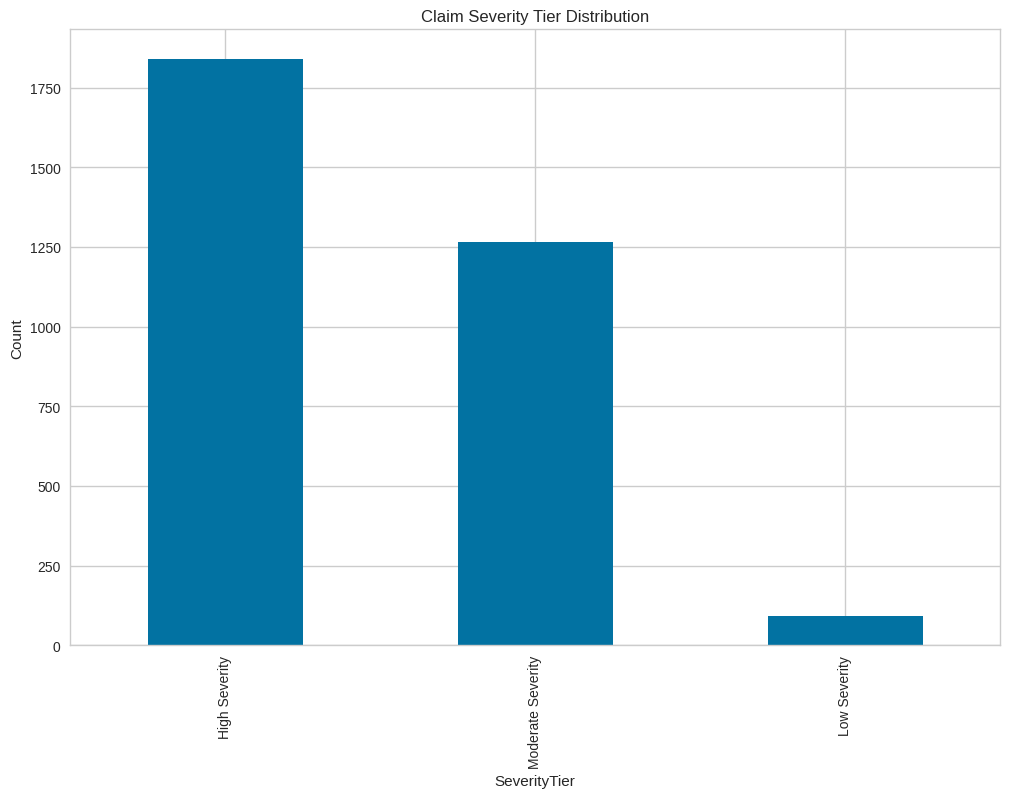

In [4]:
severity_df["SeverityTier"].value_counts().plot(kind="bar")
plt.title("Claim Severity Tier Distribution")
plt.ylabel("Count")
plt.show()

#### **Histograms of predictors**

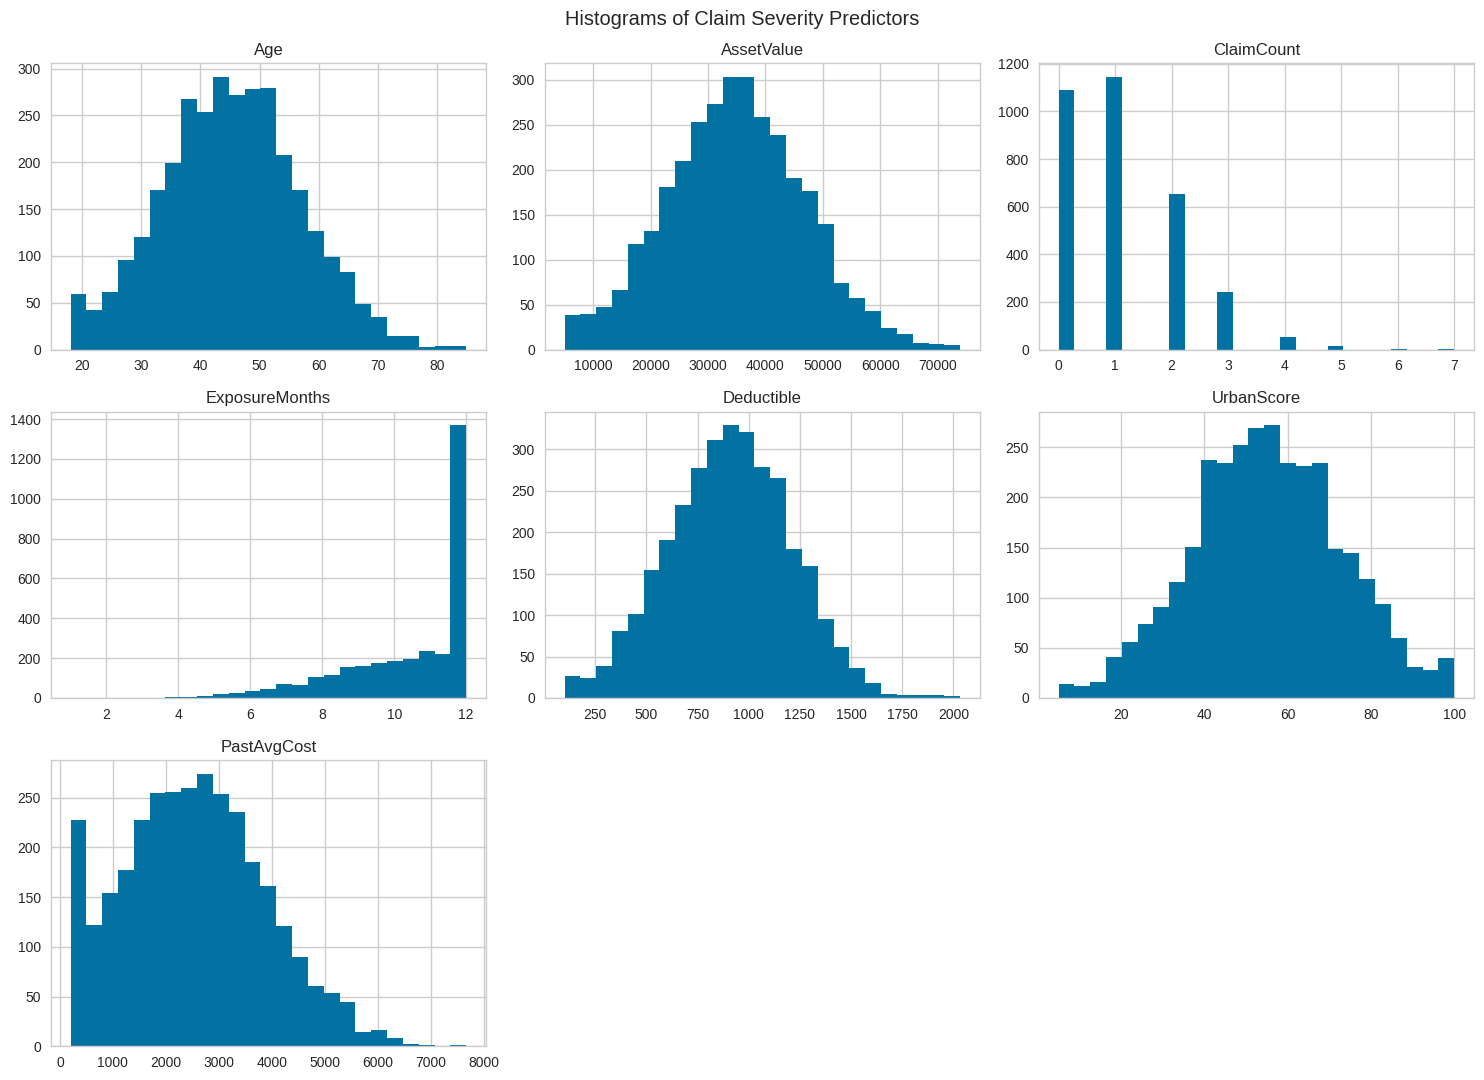

In [5]:
severity_df.hist(figsize=(15, 11), bins=25)
plt.suptitle("Histograms of Claim Severity Predictors")
plt.tight_layout()
plt.show()

#### **Boxplots by severity tier**

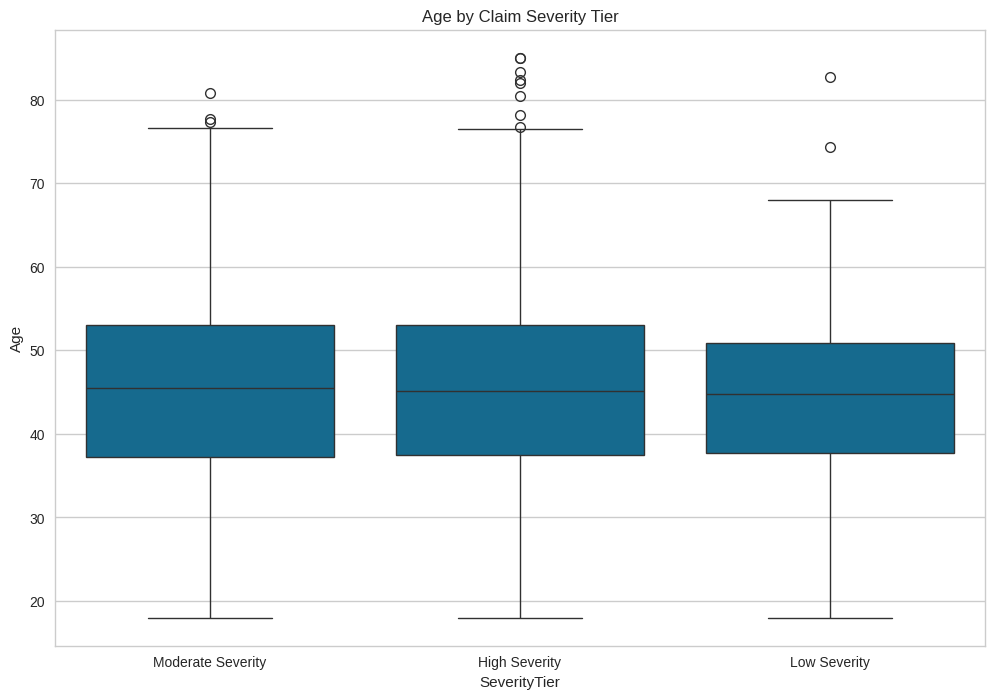

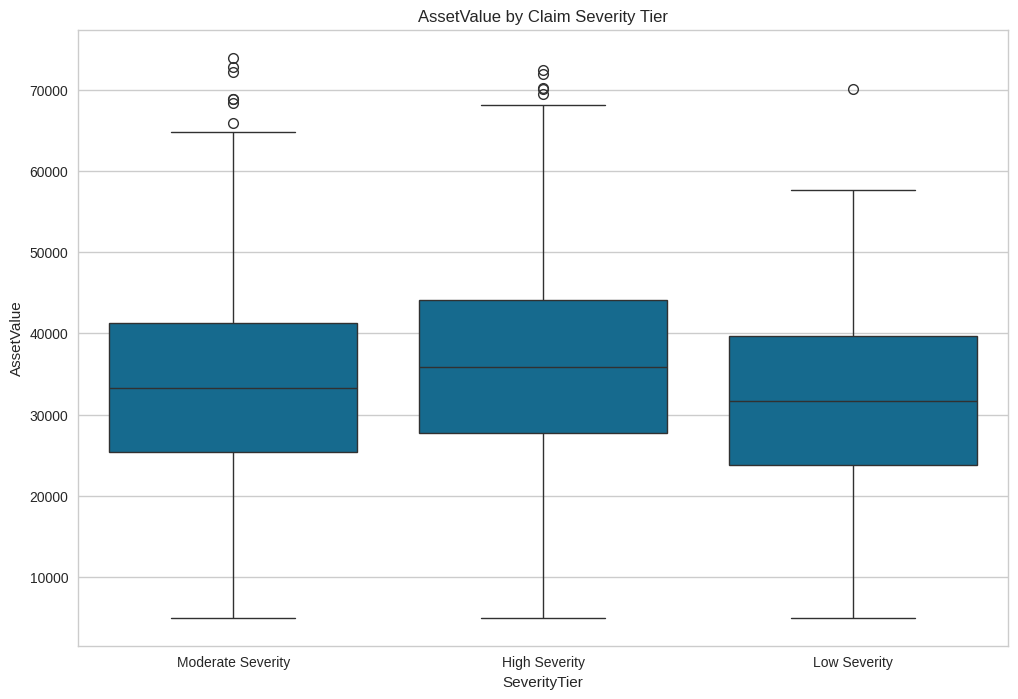

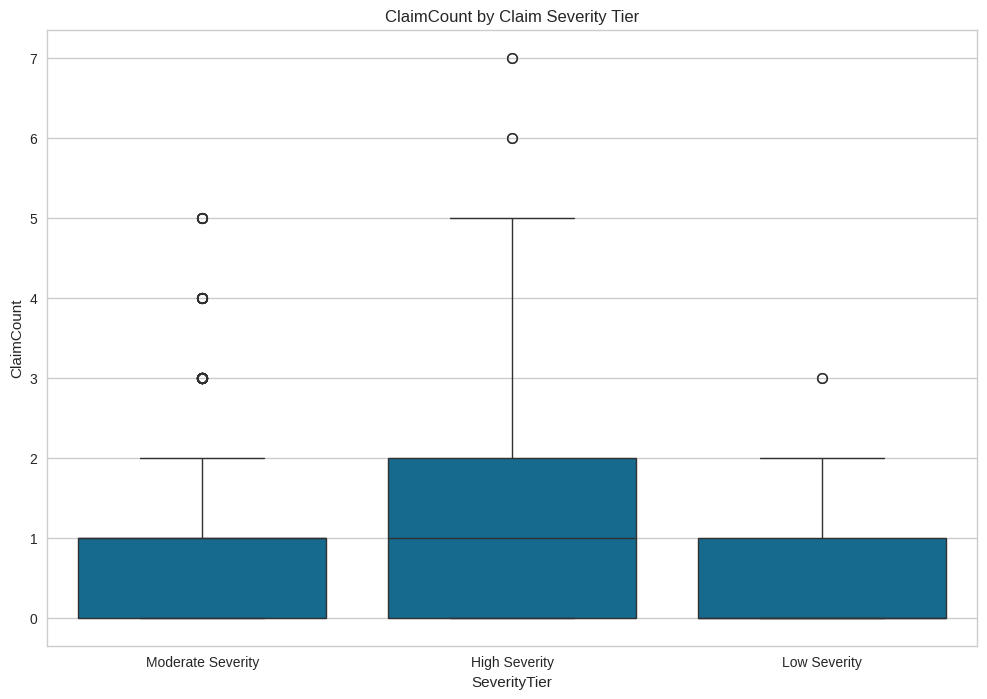

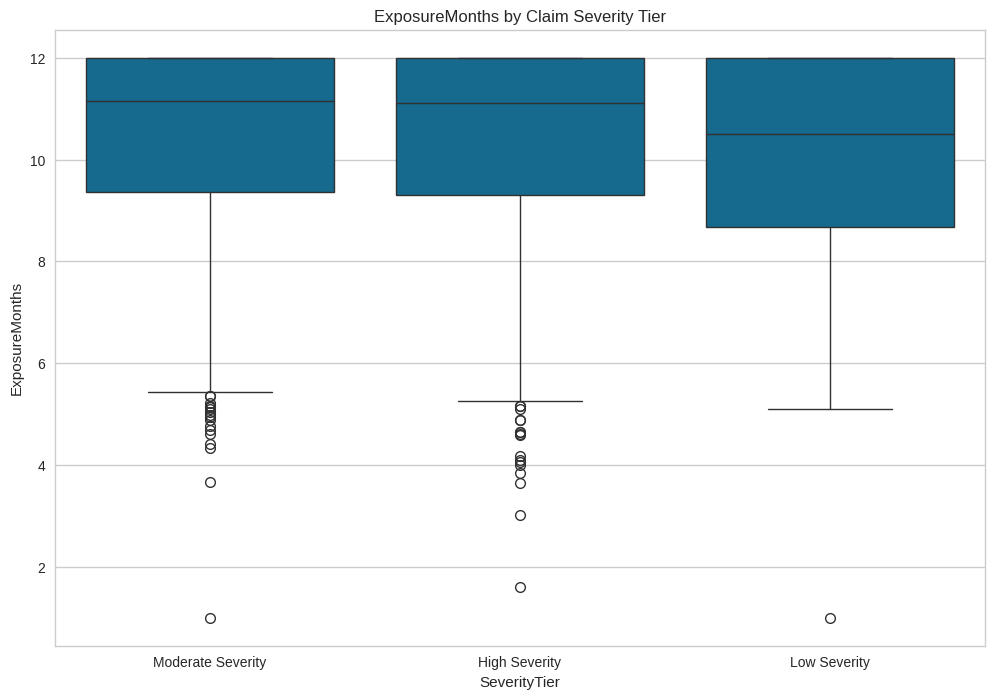

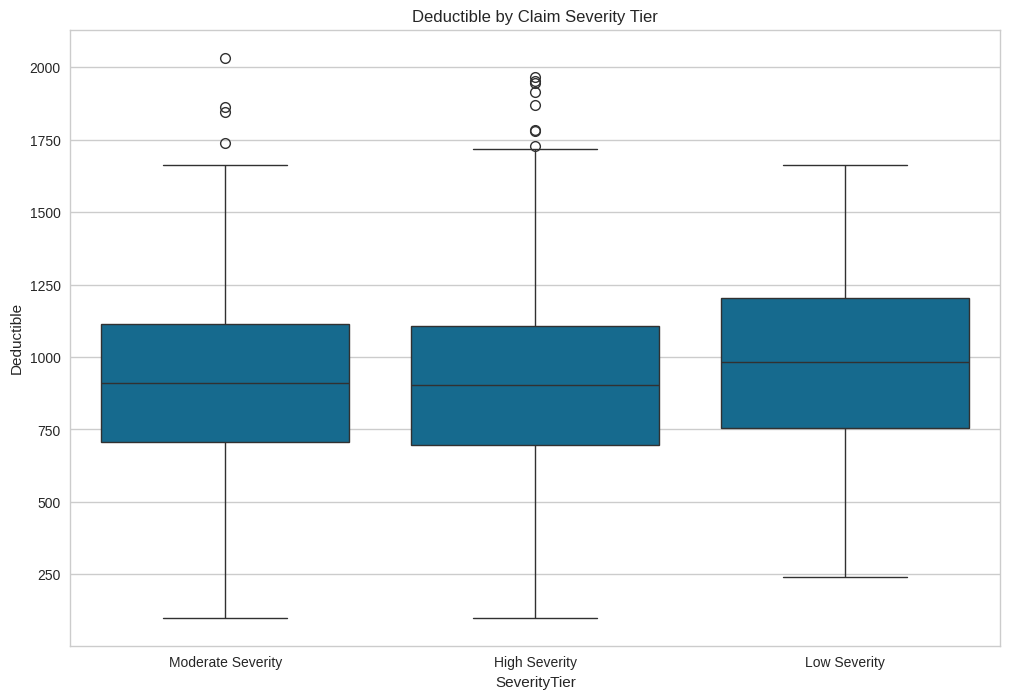

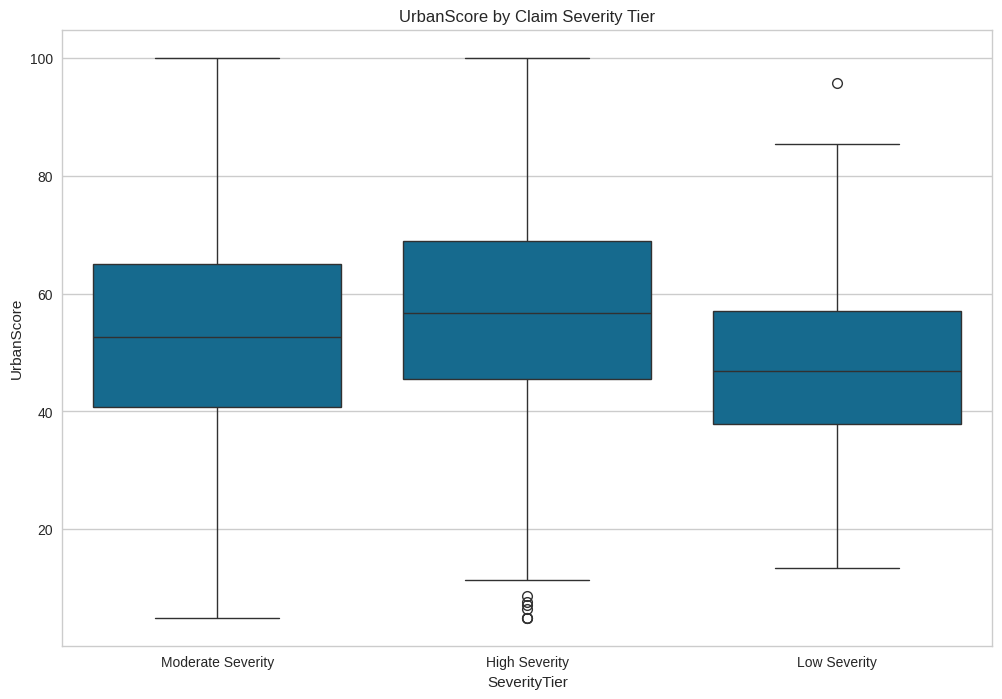

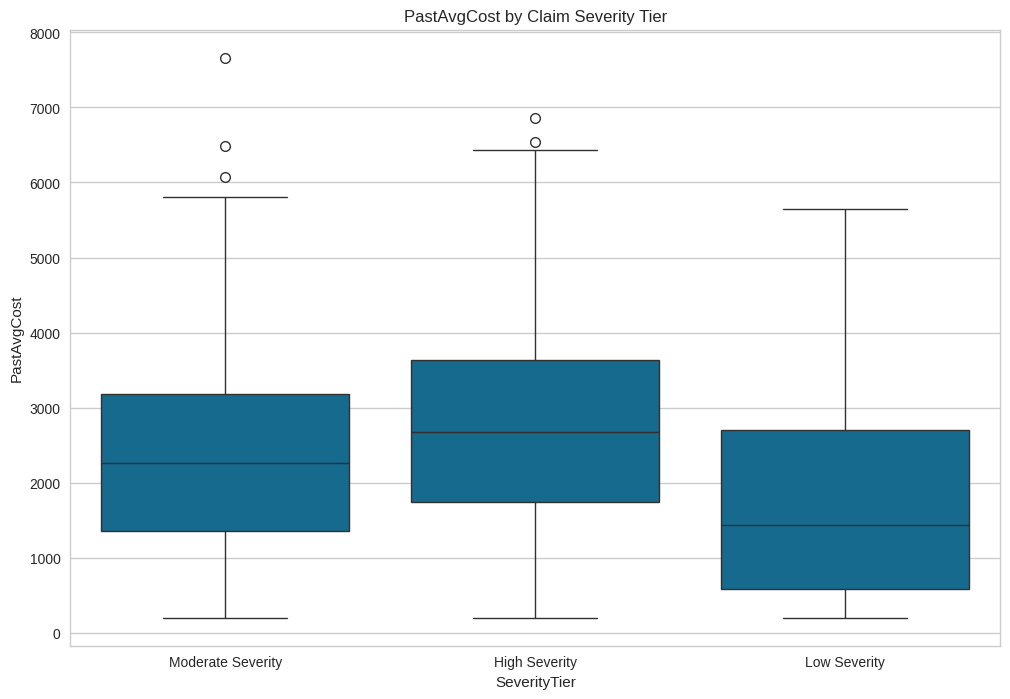

In [6]:
for col in ["Age", "AssetValue", "ClaimCount", "ExposureMonths", "Deductible", "UrbanScore", "PastAvgCost"]:
  sns.boxplot(data=severity_df, x="SeverityTier", y=col)
  plt.title(f"{col} by Claim Severity Tier")
  plt.show()

#### **Correlation heatmap**

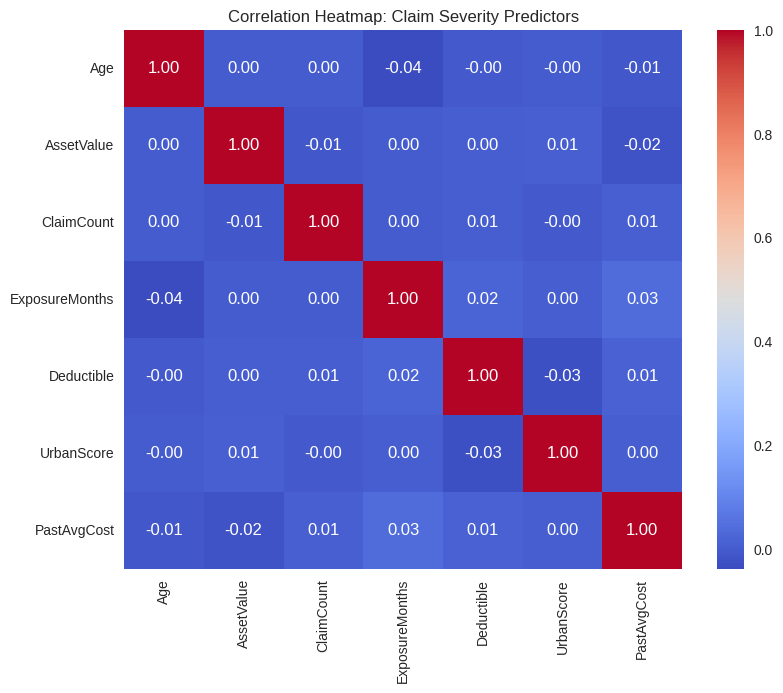

In [7]:
plt.figure(figsize=(9, 7))
sns.heatmap(severity_df.drop(columns="SeverityTier").corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap: Claim Severity Predictors")
plt.show()

#### **Pairplot**

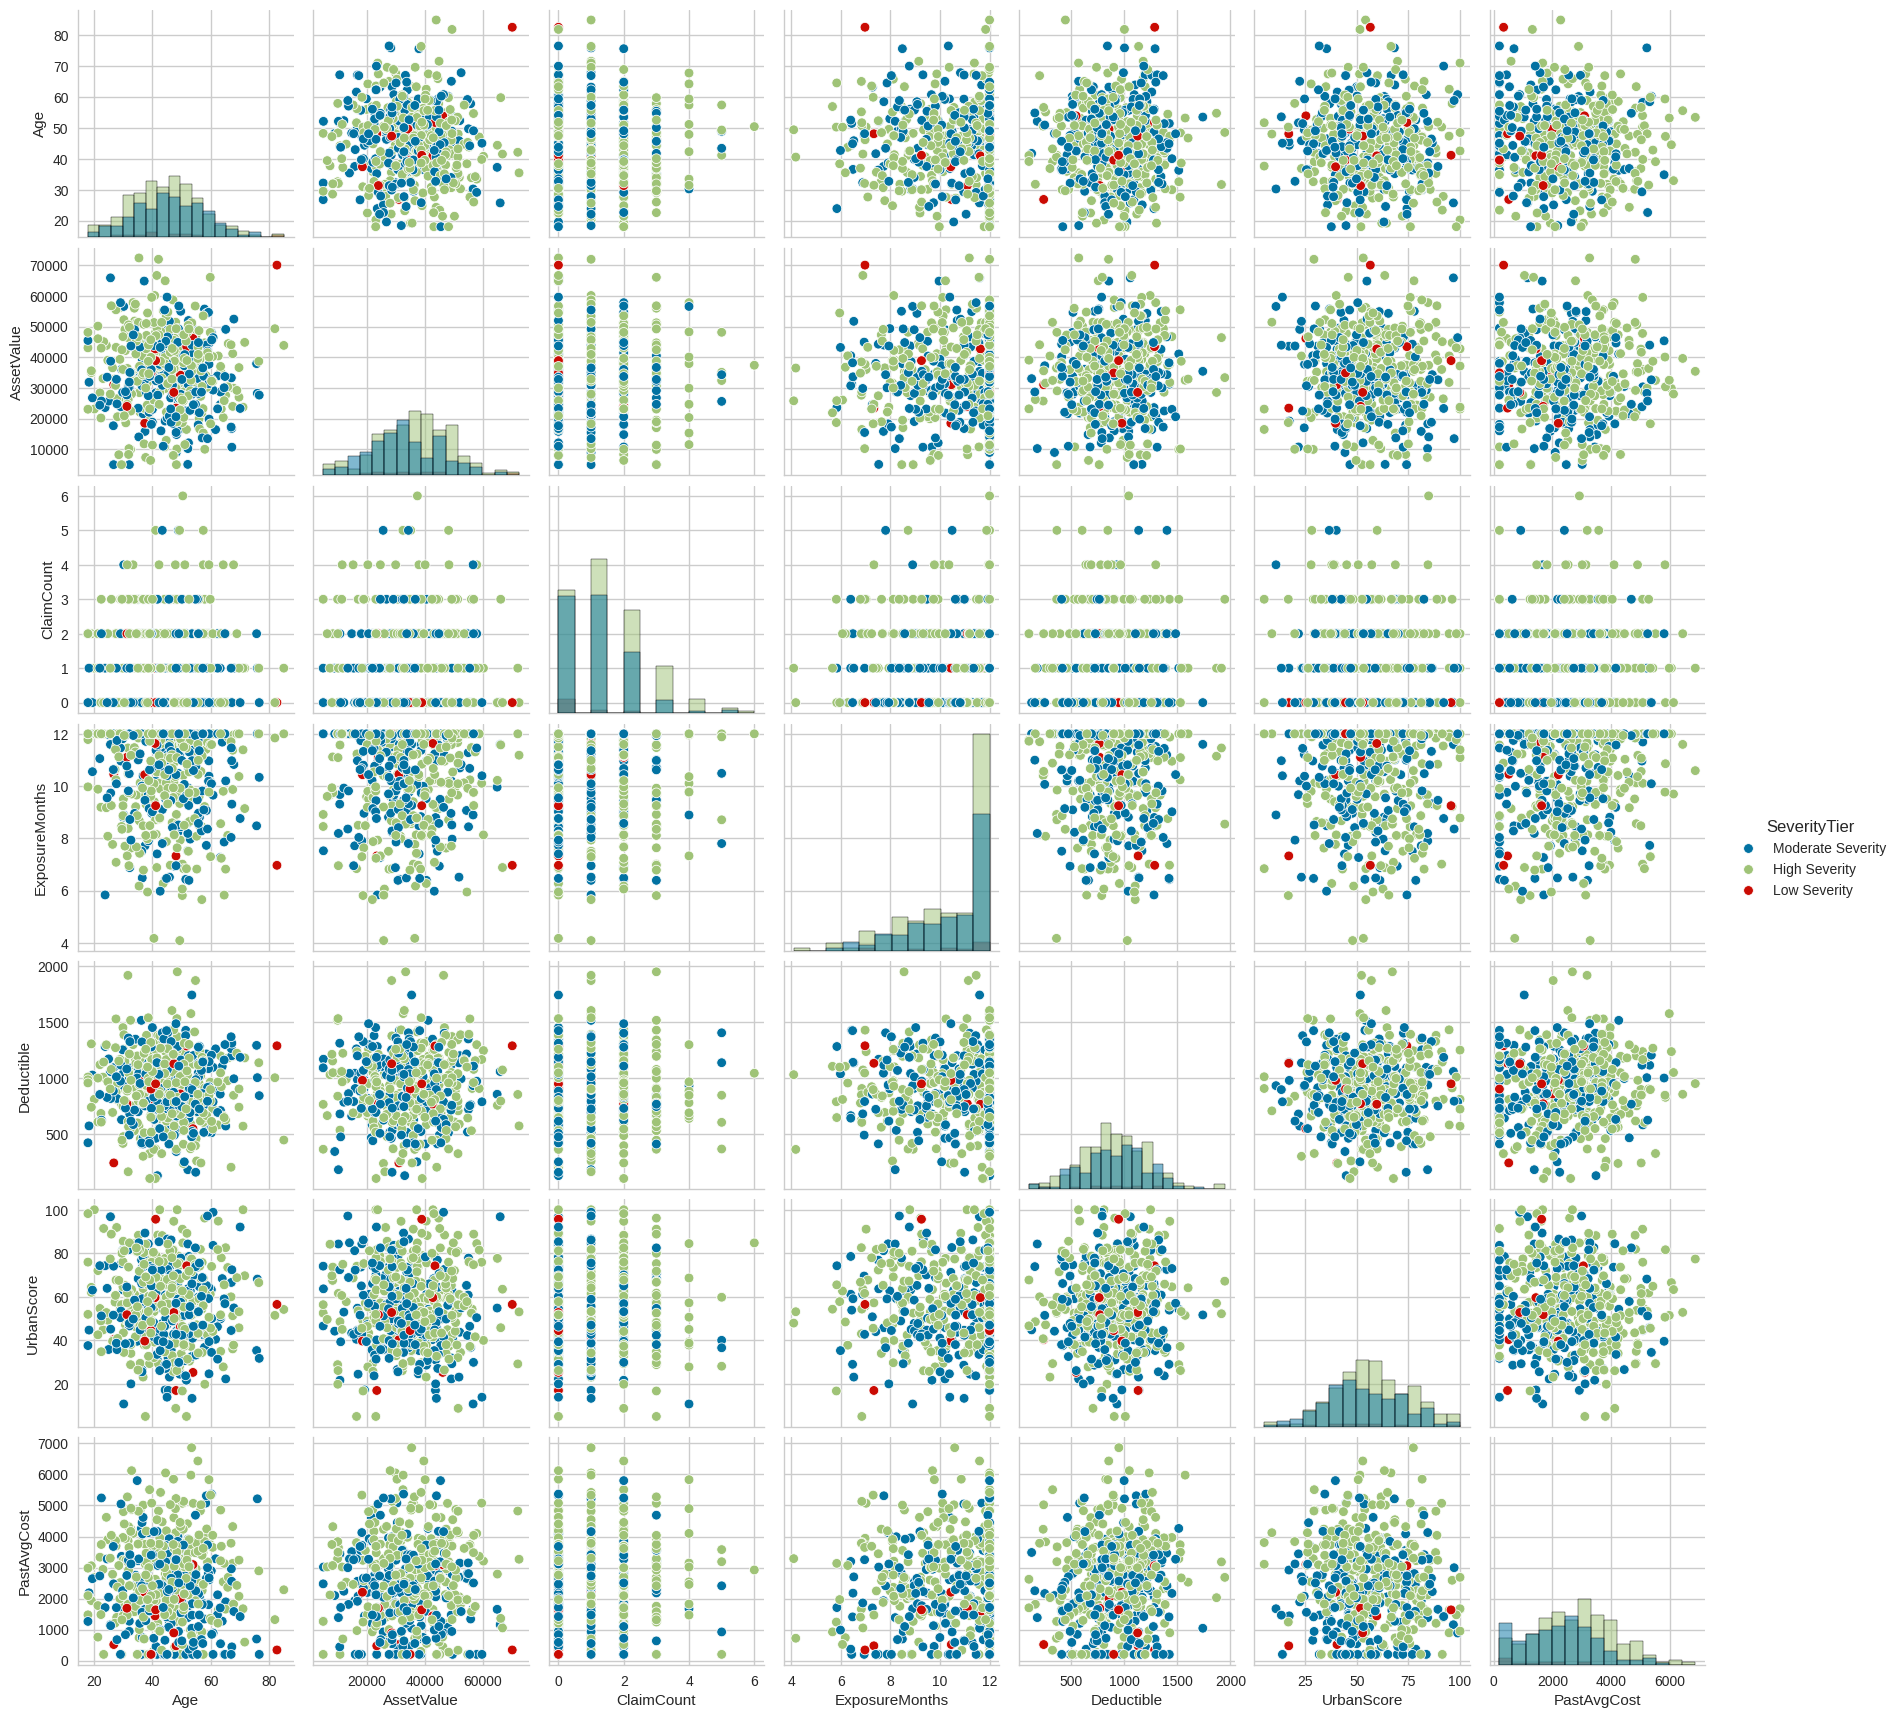

In [8]:
sns.pairplot(
  severity_df.sample(500, random_state=42),
  hue="SeverityTier",
  diag_kind="hist"
)
plt.show()

#### **Fitting the multinomial logistic regression model**

In [9]:
X1 = severity_df.drop(columns="SeverityTier")
y1 = severity_df["SeverityTier"]

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.30, random_state=42, stratify=y1
)

severity_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        multi_class="multinomial",
        solver="lbfgs",
        max_iter=2000
    ))
])

severity_model.fit(X1_train, y1_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(max_iter=2000, multi_class='multinomial'))])

#### **Accuracy and classification report**

In [10]:
y1_pred = severity_model.predict(X1_test)
y1_prob = severity_model.predict_proba(X1_test)

print("Accuracy:", accuracy_score(y1_test, y1_pred))

report = classification_report(y1_test, y1_pred)
print(report)

Accuracy: 0.6260416666666667
                   precision    recall  f1-score   support

    High Severity       0.64      0.85      0.73       552
     Low Severity       0.00      0.00      0.00        28
Moderate Severity       0.57      0.35      0.43       380

         accuracy                           0.63       960
        macro avg       0.40      0.40      0.39       960
     weighted avg       0.60      0.63      0.59       960



In [11]:
display(plot_classification_report(y1_test, y1_pred))

,precision,recall,f1-score,support
High Severity,0.645,0.848,0.732,552.000
Low Severity,0.000,0.000,0.000,28.000
Moderate Severity,0.568,0.350,0.433,380.000
accuracy,0.626,0.626,0.626,0.626
macro avg,0.404,0.399,0.389,960.000
weighted avg,0.596,0.626,0.593,960.000


```python
# Instantiate the visualizer
visualizer = ClassificationReport(severity_model, classes=['Class 0', 'Class 1'], support=True)

# Fit and score
visualizer.fit(X1_train, y1_train)
visualizer.score(X1_test, y1_test)
visualizer.show() # Displays the heatmap in notebook
```

#### **Confusion matrix**

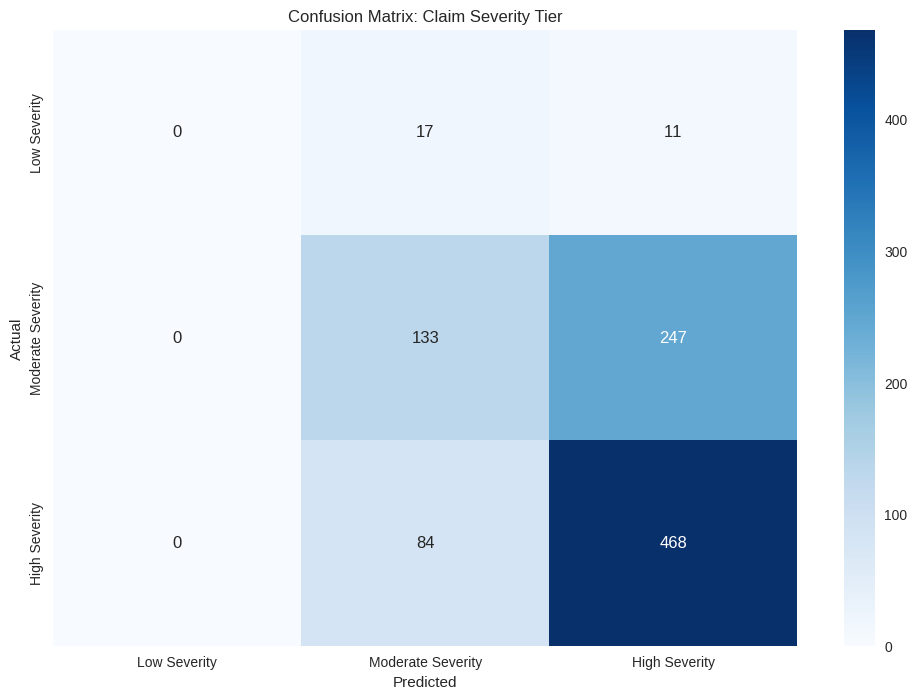

In [12]:
cm1 = confusion_matrix(y1_test, y1_pred, labels=severity_classes)
sns.heatmap(cm1, annot=True, fmt="d", cmap="Blues",
            xticklabels=severity_classes, yticklabels=severity_classes)
plt.title("Confusion Matrix: Claim Severity Tier")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### **ROC curves**

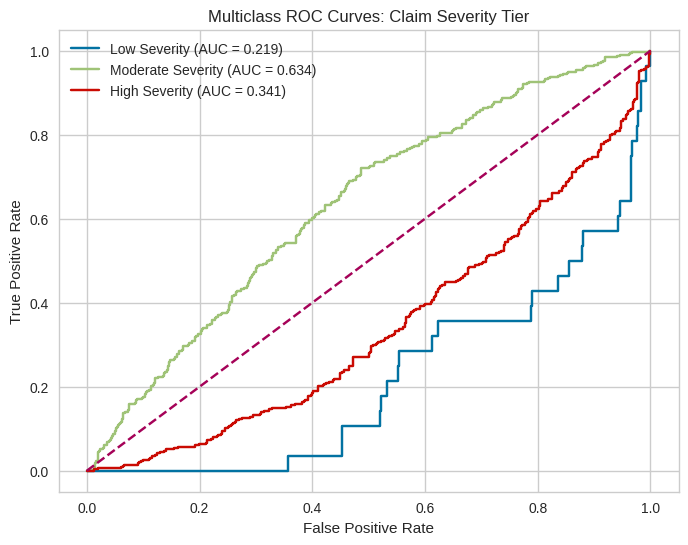

In [13]:
y1_test_bin = label_binarize(y1_test, classes=severity_classes)
plt.figure(figsize=(8, 6))

for i, cls in enumerate(severity_classes):
    fpr, tpr, _ = roc_curve(y1_test_bin[:, i], y1_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cls} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("Multiclass ROC Curves: Claim Severity Tier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

#### **Log loss**

In [14]:
print("Log Loss:", log_loss(y1_test, y1_prob, labels=severity_classes))

Log Loss: 0.7356599312803425


#### **Coefficients**

In [15]:
coef_df1 = pd.DataFrame(
    severity_model.named_steps["model"].coef_,
    columns=X1.columns,
    index=severity_model.named_steps["model"].classes_
)
display(coef_df1)

,Age,AssetValue,ClaimCount,ExposureMonths,Deductible,UrbanScore,PastAvgCost
High Severity,0.0242,0.2233,0.3868,0.0672,-0.0584,0.2630,0.4068
Low Severity,-0.0740,-0.1912,-0.4672,-0.1948,0.1200,-0.2533,-0.4686
Moderate Severity,0.0498,-0.0321,0.0805,0.1276,-0.0616,-0.0098,0.0618


#### **Coefficient heatmap**

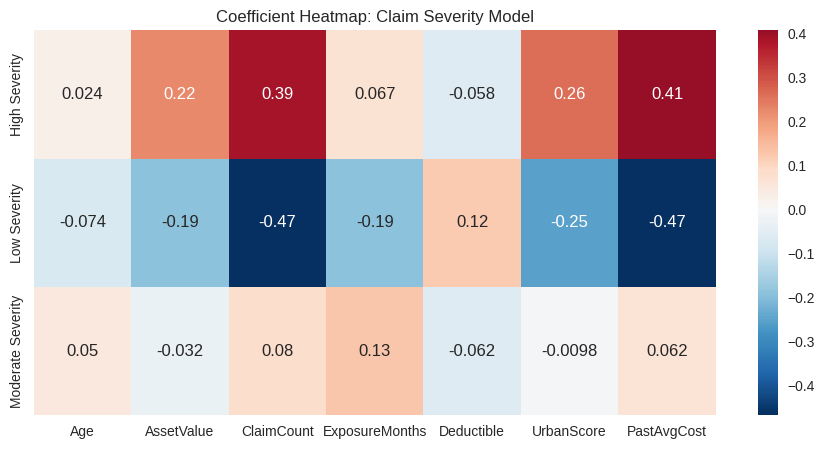

In [16]:
plt.figure(figsize=(11, 5))
sns.heatmap(coef_df1, annot=True, cmap="RdBu_r", center=0)
plt.title("Coefficient Heatmap: Claim Severity Model")
plt.show()

#### **Partial dependence plots**

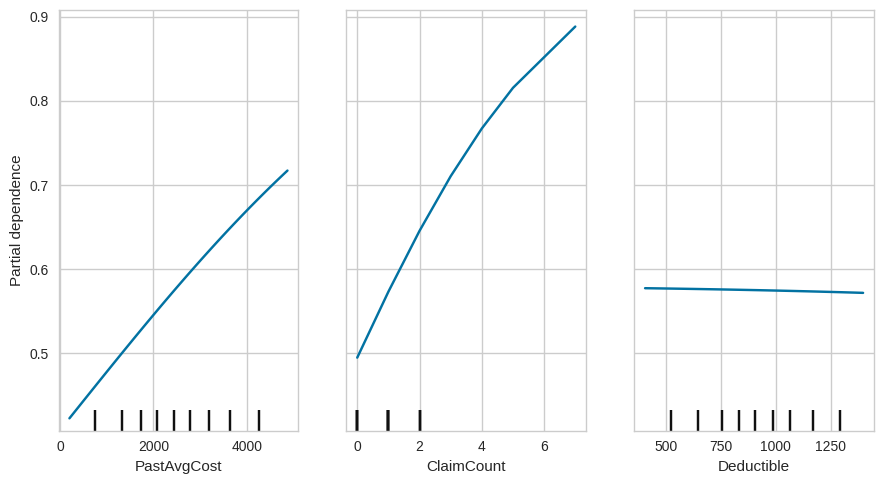

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
PartialDependenceDisplay.from_estimator(
    severity_model, X1_train, ["PastAvgCost", "ClaimCount", "Deductible"], ax=ax, target="High Severity"
)
plt.tight_layout()
plt.show()

#### **Scenario analysis**

In [18]:
severity_scenarios = pd.DataFrame({
    "Age": [30, 48, 67],
    "AssetValue": [18000, 42000, 85000],
    "ClaimCount": [0, 2, 5],
    "ExposureMonths": [10, 12, 12],
    "Deductible": [1800, 900, 250],
    "UrbanScore": [25, 60, 90],
    "PastAvgCost": [700, 2800, 7800]
}, index=["Low-Risk Policyholder", "Standard Portfolio Case", "Adverse Severity Case"])

severity_scenario_probs = pd.DataFrame(
    severity_model.predict_proba(severity_scenarios),
    columns=severity_model.named_steps["model"].classes_,
    index=severity_scenarios.index
)

display(severity_scenario_probs)

,High Severity,Low Severity,Moderate Severity
Low-Risk Policyholder,0.1594,0.3318,0.5088
Standard Portfolio Case,0.7116,0.0042,0.2843
Adverse Severity Case,0.9884,0.0000,0.0116


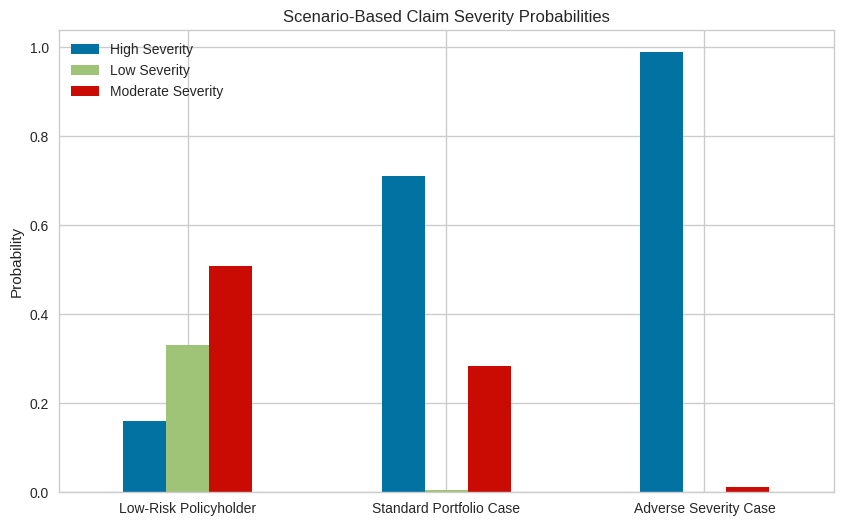

In [19]:
severity_scenario_probs.plot(kind="bar", figsize=(10, 6))
plt.title("Scenario-Based Claim Severity Probabilities")
plt.ylabel("Probability")
plt.xticks(rotation=0)
plt.show()

> *The real business value of multinomial logistic regression is not just classification. It is scenario-based probability insight.*

---
#### **Case Study 2: Policy Lapse State Classification**
---

In [20]:
np.random.seed(123)
n2 = 3000

policy_duration = np.random.normal(6, 3, n2).clip(0.2, 20)
premium_change = np.random.normal(8, 6, n2).clip(-10, 35)
payment_index = np.random.normal(50, 15, n2).clip(5, 100)
channel_score = np.random.normal(60, 18, n2).clip(5, 100)
customer_tenure = np.random.normal(7, 4, n2).clip(0.2, 25)
complaints = np.random.poisson(0.8, n2).clip(0, 10)
competitiveness = np.random.normal(55, 16, n2).clip(5, 100)

score_retained = (
    2.2
    + 0.10*policy_duration
    - 0.09*premium_change
    + 0.01*payment_index
    + 0.02*channel_score
    + 0.08*customer_tenure
    - 0.35*complaints
    + 0.025*competitiveness
)

score_late = (
    0.9
    + 0.02*policy_duration
    + 0.04*premium_change
    - 0.002*payment_index
    - 0.003*channel_score
    + 0.01*customer_tenure
    + 0.10*complaints
    - 0.008*competitiveness
)

score_early = (
    -1.8
    - 0.10*policy_duration
    + 0.11*premium_change
    - 0.01*payment_index
    - 0.02*channel_score
    - 0.07*customer_tenure
    + 0.28*complaints
    - 0.02*competitiveness
)

scores2 = np.vstack([score_retained, score_late, score_early]).T
exp_scores2 = np.exp(scores2 - scores2.max(axis=1, keepdims=True))
probs2 = exp_scores2 / exp_scores2.sum(axis=1, keepdims=True)

lapse_classes = np.array(["Retained", "Late Lapse", "Early Lapse"])
y_lapse = np.array([np.random.choice(lapse_classes, p=p) for p in probs2])

lapse_df = pd.DataFrame({
    "PolicyDuration": policy_duration,
    "PremiumChangePct": premium_change,
    "PaymentIndex": payment_index,
    "ChannelScore": channel_score,
    "CustomerTenure": customer_tenure,
    "Complaints": complaints,
    "Competitiveness": competitiveness,
    "LapseState": y_lapse
})
display(lapse_df.head(15))

,PolicyDuration,PremiumChangePct,PaymentIndex,ChannelScore,CustomerTenure,Complaints,Competitiveness,LapseState
0,2.7431,5.2964,53.4036,80.3677,1.5446,1,59.5213,Retained
1,8.9920,11.6575,14.0217,54.2128,4.6209,1,40.3254,Retained
2,6.8489,15.0425,43.2821,67.0587,11.5752,0,77.2345,Retained
3,1.4811,13.2309,52.9608,50.2440,2.6099,1,67.1065,Retained
4,4.2642,19.4283,59.4105,32.7591,5.1516,0,83.7738,Retained
5,10.9543,8.8009,66.5814,64.7187,5.8750,0,54.9998,Retained
6,0.2000,15.6911,56.3832,30.4406,4.0894,0,57.9516,Retained
7,4.7133,1.0449,34.0916,74.5810,4.7960,2,63.8215,Retained
8,9.7978,13.2230,47.7414,58.7449,9.4394,0,66.2312,Retained
9,3.3998,6.7422,77.4341,43.7731,5.8053,0,31.7954,Retained


#### **Class distribution**

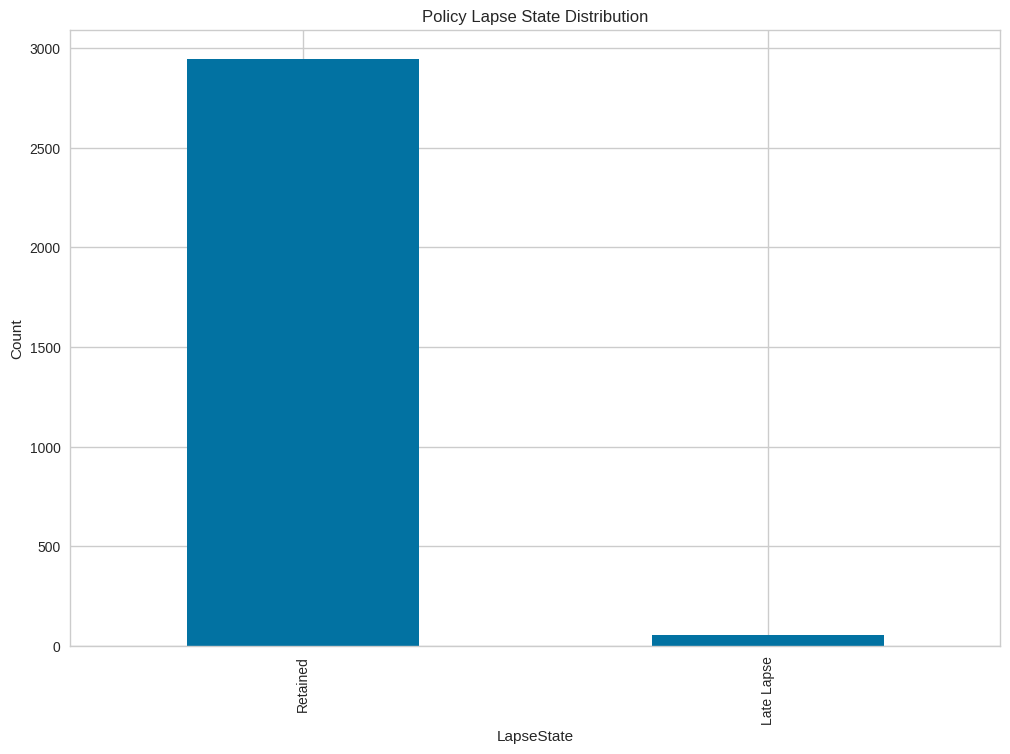

In [21]:
lapse_df["LapseState"].value_counts().plot(kind="bar")
plt.title("Policy Lapse State Distribution")
plt.ylabel("Count")
plt.show()

#### **Histograms**

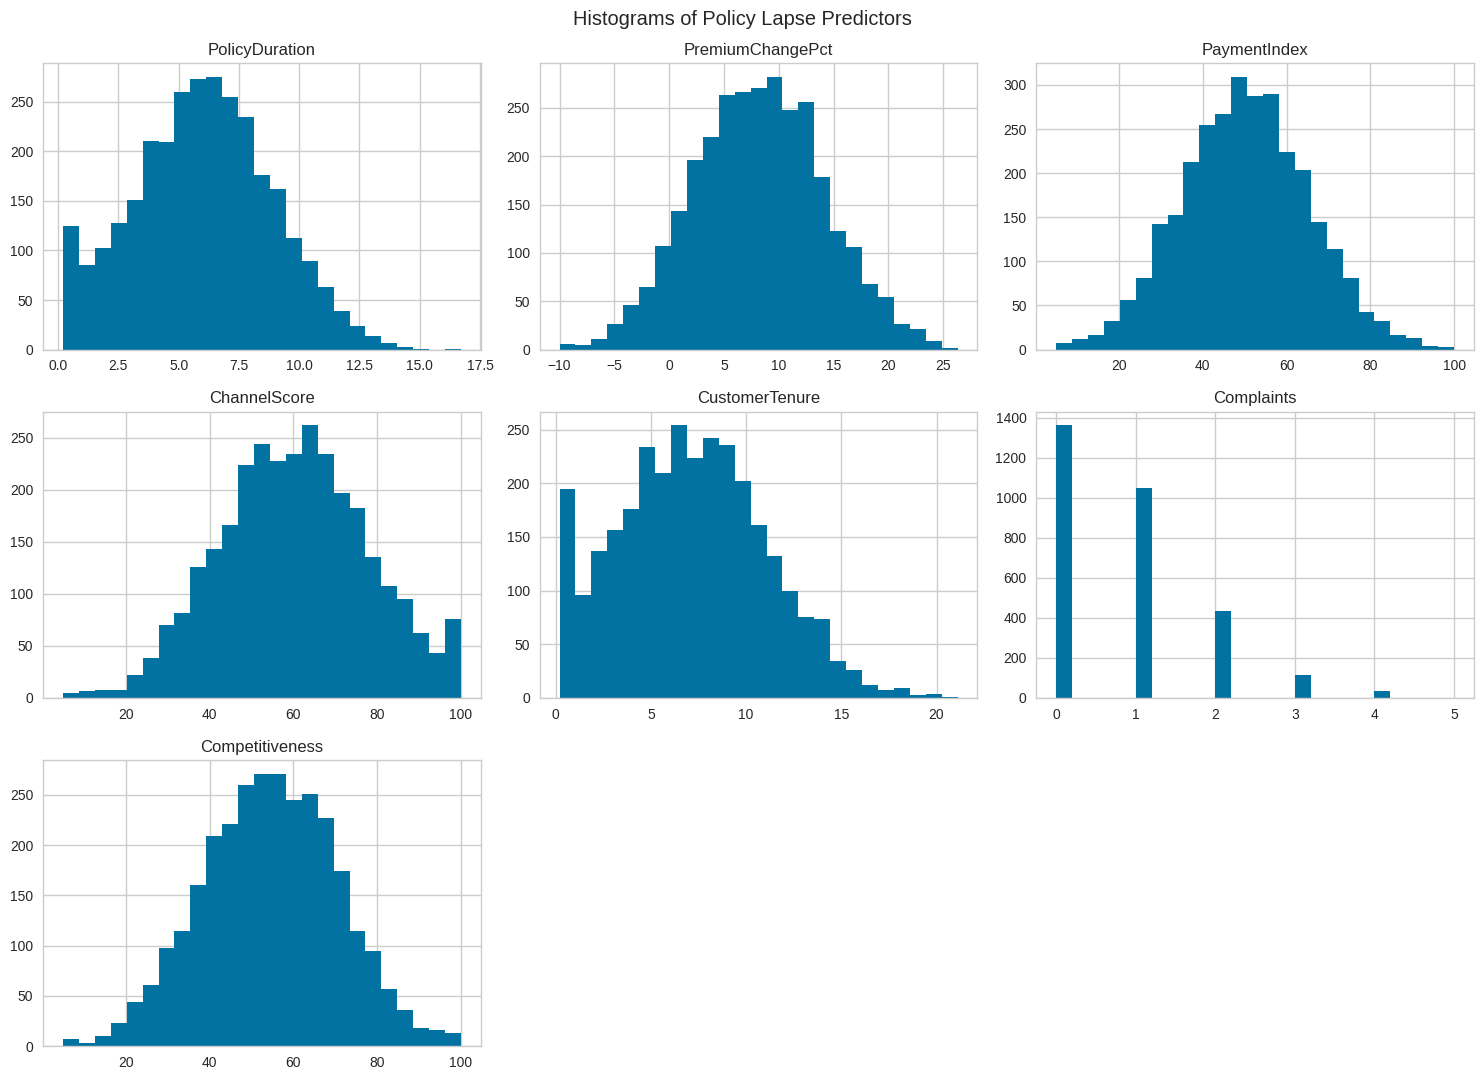

In [22]:
lapse_df.hist(figsize=(15, 11), bins=25)
plt.suptitle("Histograms of Policy Lapse Predictors")
plt.tight_layout()
plt.show()

#### **Boxplots by class**

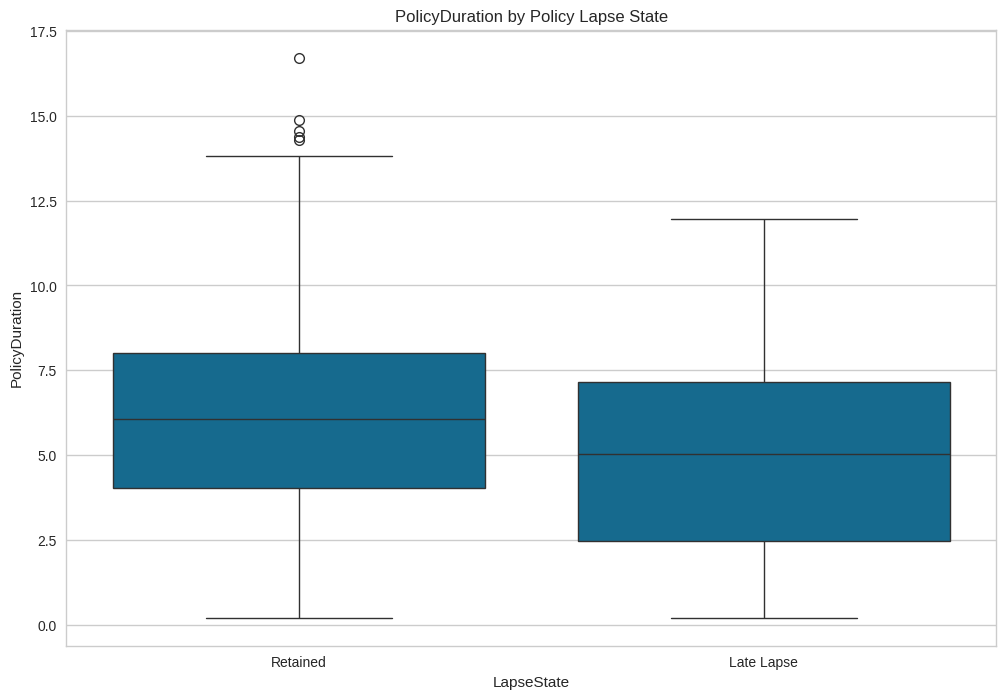

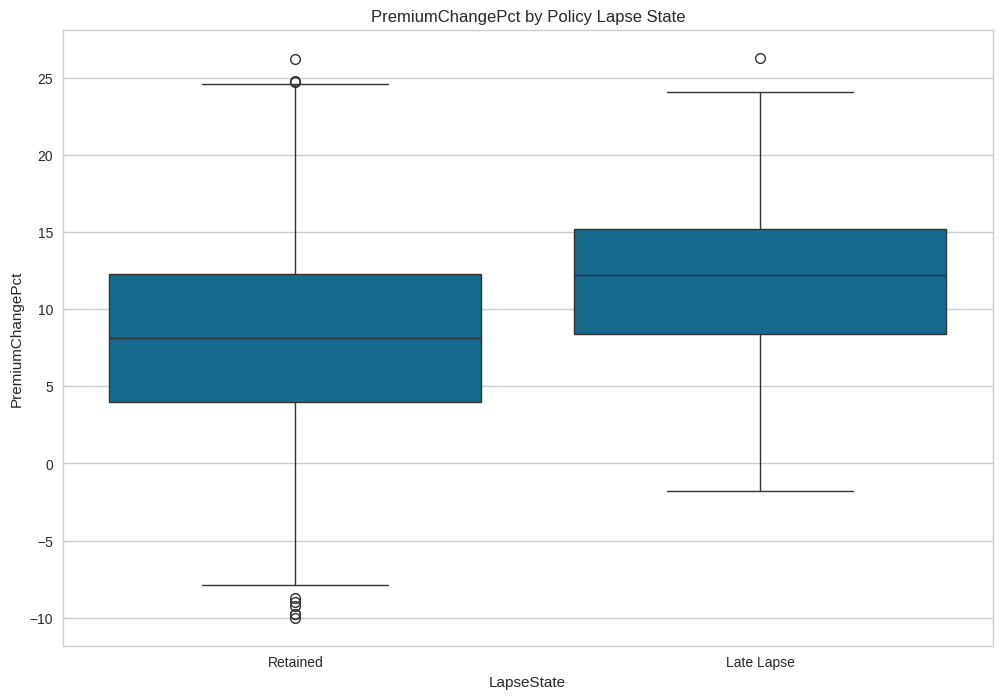

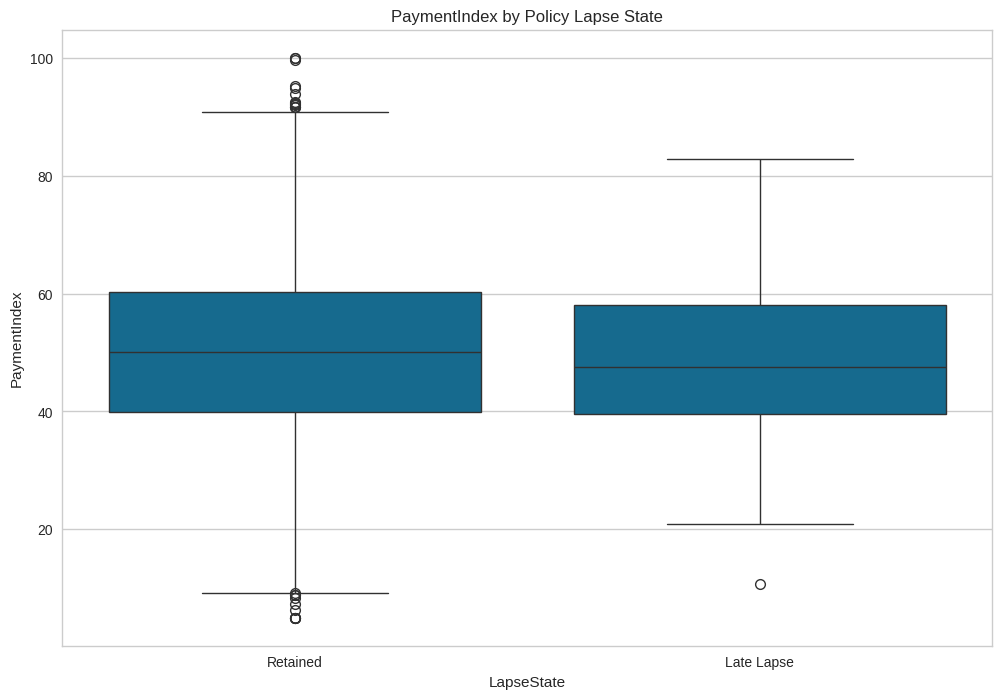

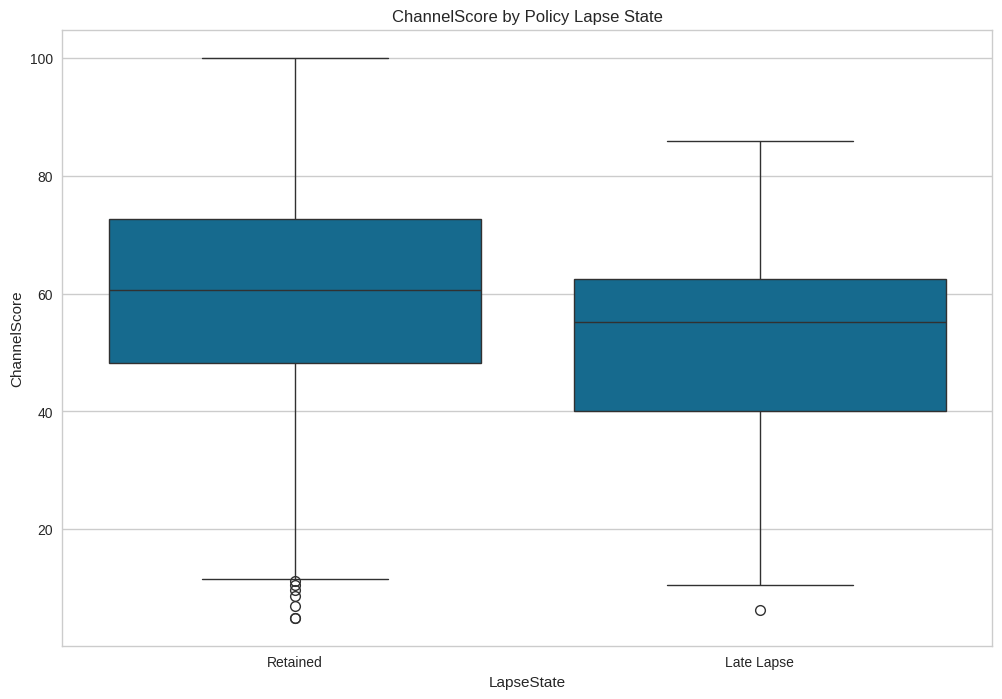

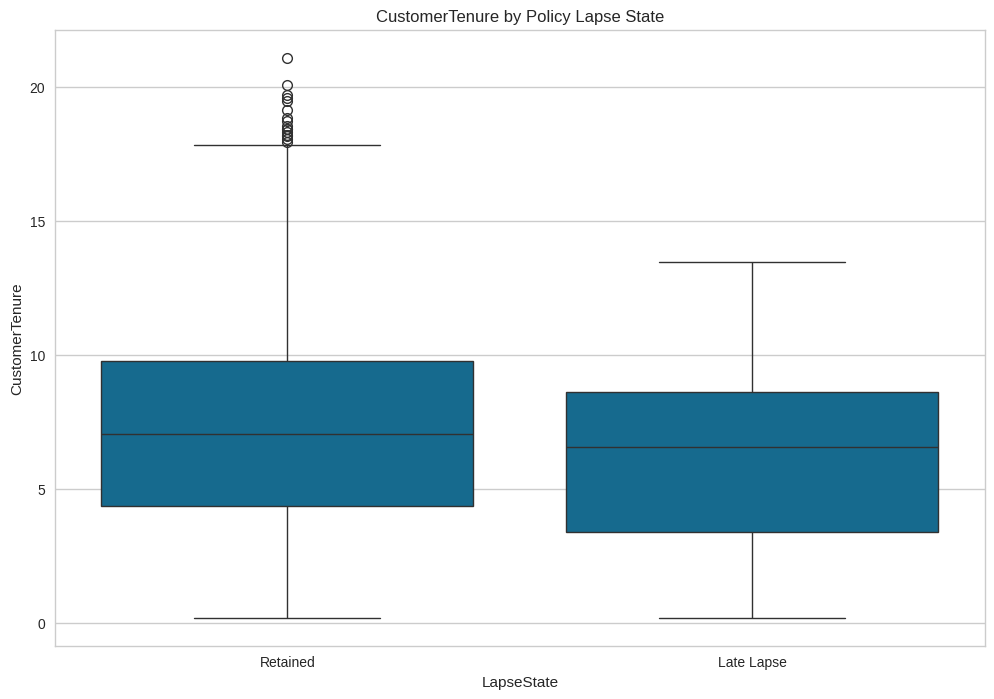

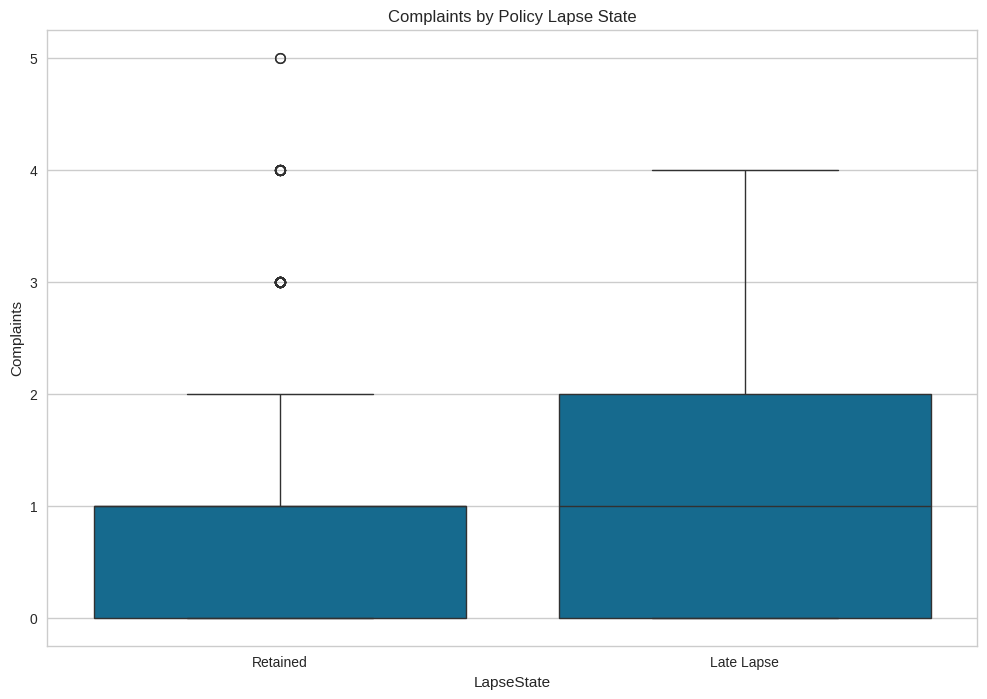

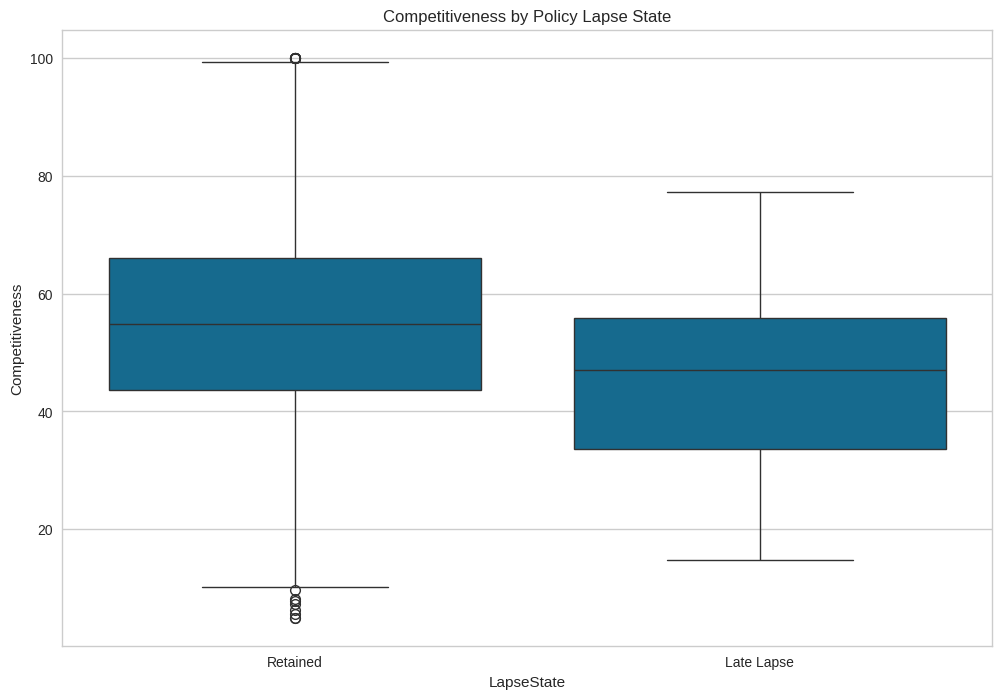

In [23]:
for col in ["PolicyDuration", "PremiumChangePct", "PaymentIndex", "ChannelScore", "CustomerTenure", "Complaints", "Competitiveness"]:
  sns.boxplot(data=lapse_df, x="LapseState", y=col)
  plt.title(f"{col} by Policy Lapse State")
  plt.show()

#### **Correlation heatmap**

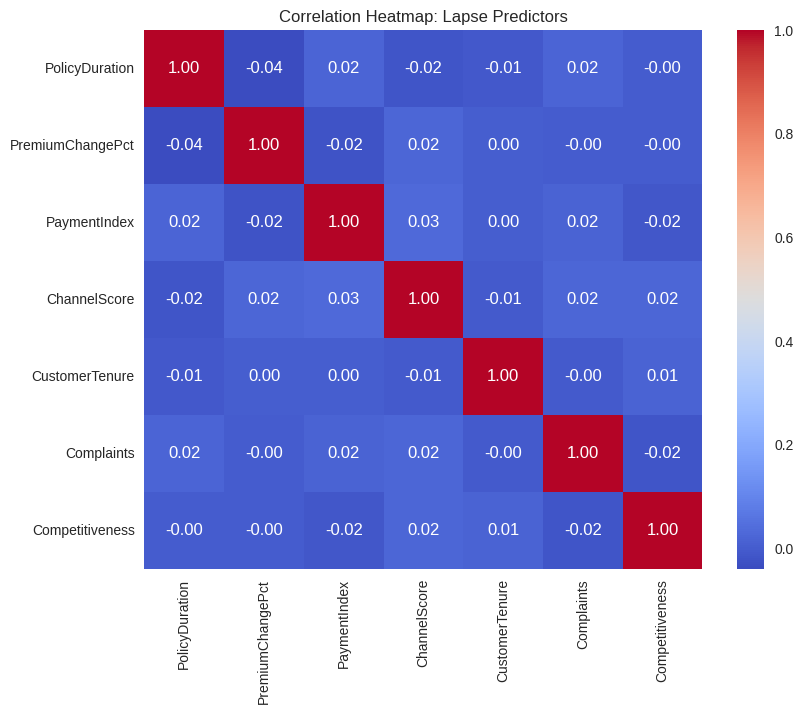

In [24]:
plt.figure(figsize=(9, 7))
sns.heatmap(lapse_df.drop(columns="LapseState").corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap: Lapse Predictors")
plt.show()

#### **Pairplot**

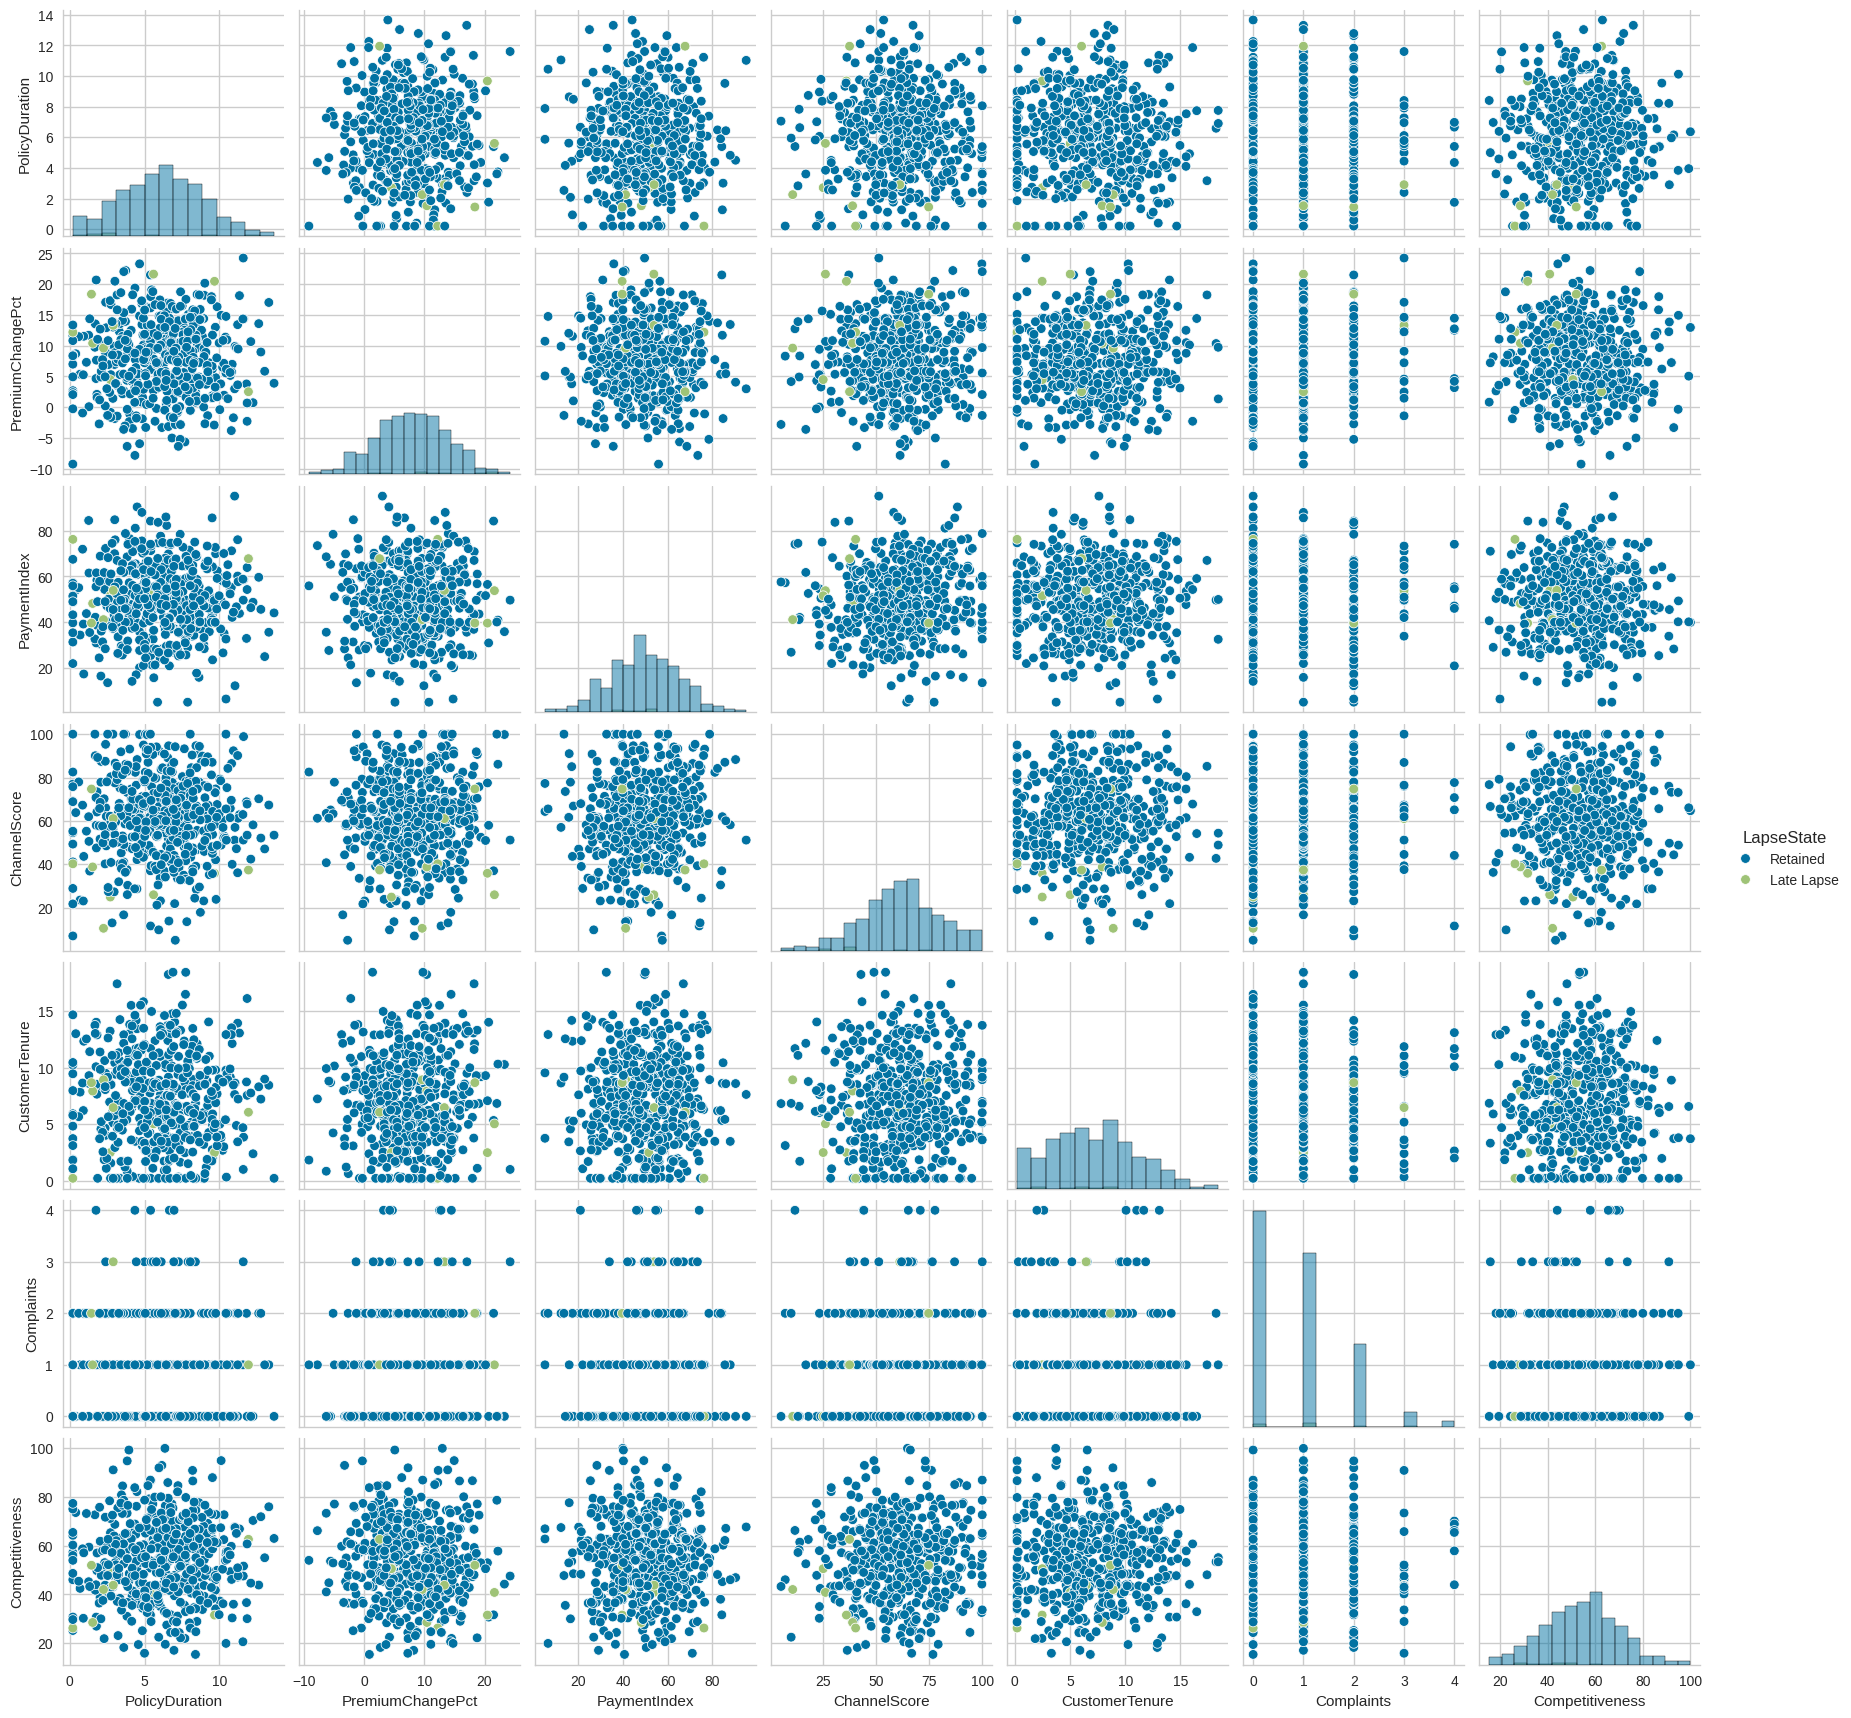

In [25]:
sns.pairplot(
  lapse_df.sample(500, random_state=42),
  hue="LapseState",
  diag_kind="hist"
)
plt.show()

#### **Fit and evaluate the lapse model**

In [26]:
X2 = lapse_df.drop(columns="LapseState")
y2 = lapse_df["LapseState"]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.30, random_state=42, stratify=y2
)

lapse_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        multi_class="multinomial",
        solver="lbfgs",
        max_iter=2000
    ))
])

lapse_model.fit(X2_train, y2_train)
y2_pred = lapse_model.predict(X2_test)
y2_prob = lapse_model.predict_proba(X2_test)

print("Accuracy:", accuracy_score(y2_test, y2_pred))

report = classification_report(y2_test, y2_pred)
print(report)

Accuracy: 0.9811111111111112
              precision    recall  f1-score   support

  Late Lapse       0.00      0.00      0.00        17
    Retained       0.98      1.00      0.99       883

    accuracy                           0.98       900
   macro avg       0.49      0.50      0.50       900
weighted avg       0.96      0.98      0.97       900



In [27]:
display(plot_classification_report(y2_test, y2_pred))

,precision,recall,f1-score,support
Late Lapse,0.000,0.000,0.000,17.000
Retained,0.981,1.000,0.990,883.000
accuracy,0.981,0.981,0.981,0.981
macro avg,0.491,0.500,0.495,900.000
weighted avg,0.963,0.981,0.972,900.000


#### **Confusion matrix**

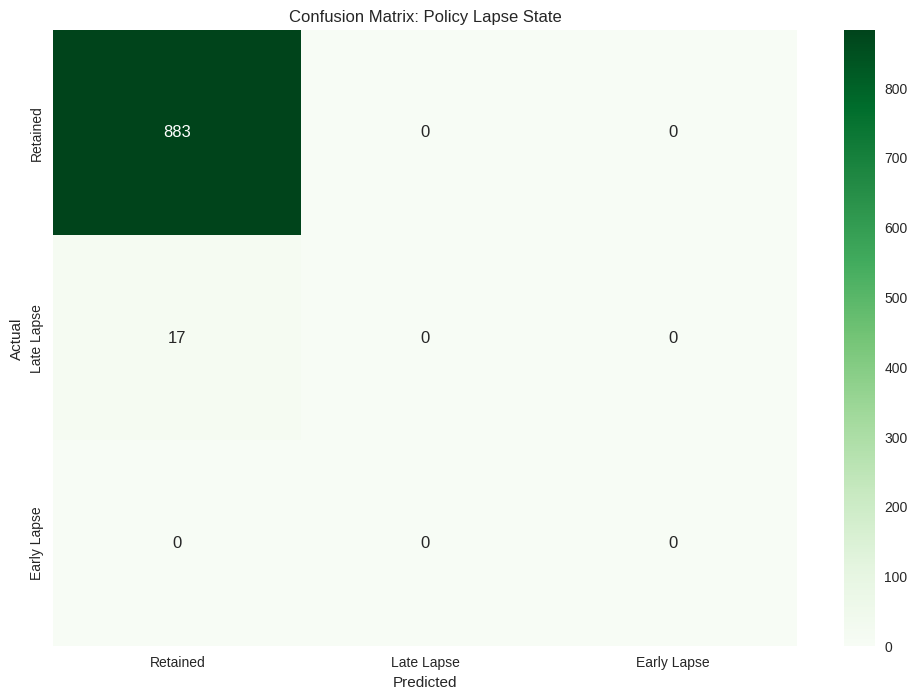

In [28]:
cm2 = confusion_matrix(y2_test, y2_pred, labels=lapse_classes)
sns.heatmap(cm2, annot=True, fmt="d", cmap="Greens",
            xticklabels=lapse_classes, yticklabels=lapse_classes)
plt.title("Confusion Matrix: Policy Lapse State")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### **ROC curves**

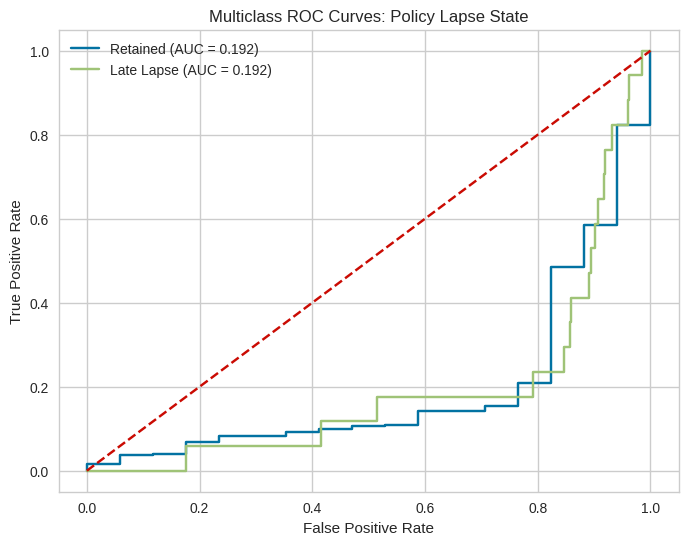

In [29]:
y2_test_bin = label_binarize(y2_test, classes=lapse_classes)
plt.figure(figsize=(8, 6))

# Only plot for the number of classes actually output by the model
num_classes_in_model = y2_prob.shape[1]

for i in range(num_classes_in_model):
  cls = lapse_classes[i]
  fpr, tpr, _ = roc_curve(y2_test_bin[:, i], y2_prob[:, i])
  roc_auc = auc(fpr, tpr)
  plt.plot(fpr, tpr, label=f"{cls} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("Multiclass ROC Curves: Policy Lapse State")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

#### **Interpreting coefficients**

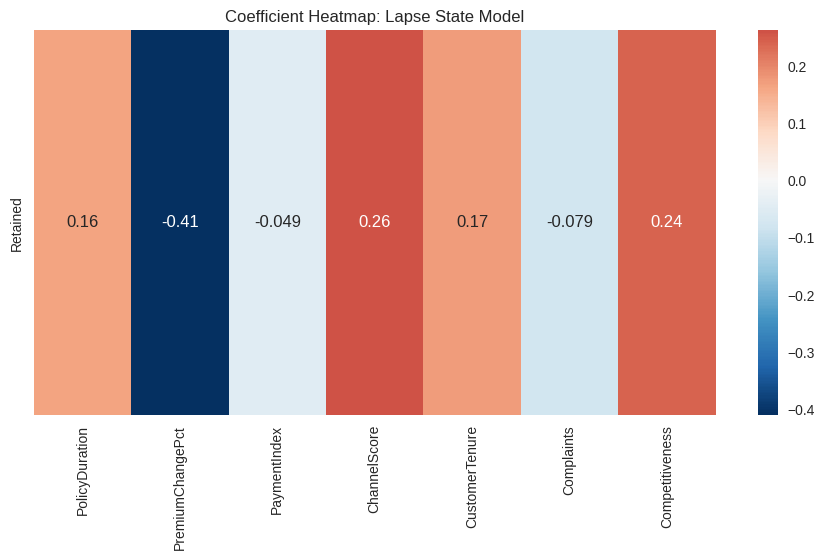

In [30]:
coef_df2 = pd.DataFrame(
    lapse_model.named_steps["model"].coef_,
    columns=X2.columns,
    index=lapse_model.named_steps["model"].classes_ if len(lapse_model.named_steps["model"].classes_) > 2 else [lapse_model.named_steps["model"].classes_[1]]
)

plt.figure(figsize=(11, 5))
sns.heatmap(coef_df2, annot=True, cmap="RdBu_r", center=0)
plt.title("Coefficient Heatmap: Lapse State Model")
plt.show()

#### **Scenario analysis**

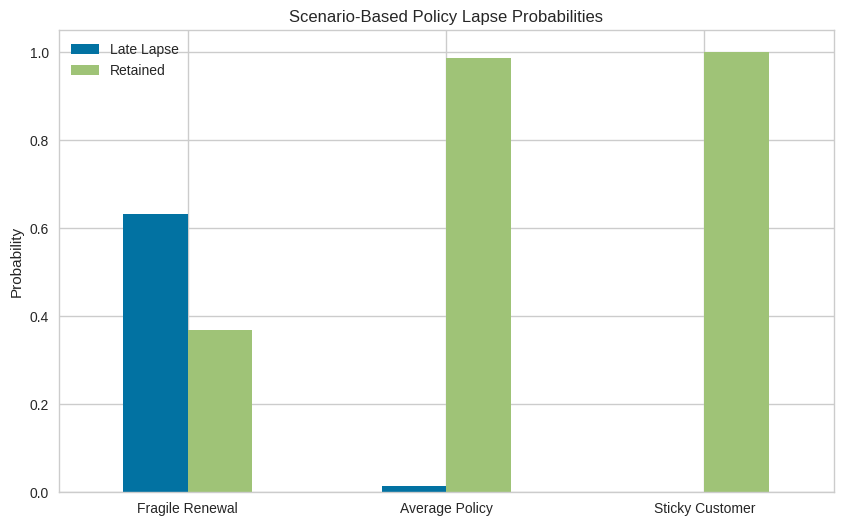

In [31]:
lapse_scenarios = pd.DataFrame({
    "PolicyDuration": [1.2, 5.5, 12.0],
    "PremiumChangePct": [24, 9, 1],
    "PaymentIndex": [35, 50, 70],
    "ChannelScore": [30, 58, 82],
    "CustomerTenure": [1, 6, 14],
    "Complaints": [3, 1, 0],
    "Competitiveness": [30, 55, 85]
}, index=["Fragile Renewal", "Average Policy", "Sticky Customer"])

lapse_scenario_probs = pd.DataFrame(
    lapse_model.predict_proba(lapse_scenarios),
    columns=lapse_model.named_steps["model"].classes_,
    index=lapse_scenarios.index
)

lapse_scenario_probs.plot(kind="bar", figsize=(10, 6))
plt.title("Scenario-Based Policy Lapse Probabilities")
plt.ylabel("Probability")
plt.xticks(rotation=0)
plt.show()

> *In lapse analytics, multinomial logistic regression helps distinguish not just whether a policy will lapse, but how and when it is likely to lapse.*

---
### **Case Study 3: Mortality Risk Band Classification**
---

In [32]:
np.random.seed(999)
n3 = 2800

age3 = np.random.normal(46, 13, n3).clip(18, 85)
bmi = np.random.normal(27, 4.8, n3).clip(16, 45)
smoker = np.random.binomial(1, 0.24, n3)
sbp = np.random.normal(128, 16, n3).clip(85, 210)
chol = np.random.normal(205, 32, n3).clip(110, 360)
chronic = np.random.poisson(1.1, n3).clip(0, 7)
family_risk = np.random.normal(50, 18, n3).clip(5, 100)

score_standard = (
    2.8
    - 0.035*age3
    - 0.06*bmi
    - 1.0*smoker
    - 0.012*sbp
    - 0.006*chol
    - 0.45*chronic
    - 0.015*family_risk
)

score_elevated = (
    1.0
    + 0.010*age3
    + 0.020*bmi
    + 0.35*smoker
    + 0.004*sbp
    + 0.002*chol
    + 0.15*chronic
    + 0.004*family_risk
)

score_highmort = (
    -2.2
    + 0.040*age3
    + 0.055*bmi
    + 1.25*smoker
    + 0.014*sbp
    + 0.007*chol
    + 0.50*chronic
    + 0.018*family_risk
)

scores3 = np.vstack([score_standard, score_elevated, score_highmort]).T
exp_scores3 = np.exp(scores3 - scores3.max(axis=1, keepdims=True))
probs3 = exp_scores3 / exp_scores3.sum(axis=1, keepdims=True)

mort_classes = np.array(["Standard Risk", "Elevated Risk", "High Mortality Risk"])
y3 = np.array([np.random.choice(mort_classes, p=p) for p in probs3])

mort_df = pd.DataFrame({
    "Age": age3,
    "BMI": bmi,
    "Smoker": smoker,
    "SBP": sbp,
    "Cholesterol": chol,
    "ChronicCount": chronic,
    "FamilyRisk": family_risk,
    "MortalityBand": y3
})

display(mort_df.head(15))

,Age,BMI,Smoker,SBP,Cholesterol,ChronicCount,FamilyRisk,MortalityBand
0,47.6531,28.5310,1,114.6162,224.7305,2,51.9705,High Mortality Risk
1,64.2246,23.7901,0,142.2136,173.7951,1,34.0427,High Mortality Risk
2,50.0926,18.0189,0,112.7139,185.1453,0,59.4306,High Mortality Risk
3,34.8402,27.6715,0,119.1869,221.3298,1,57.2688,High Mortality Risk
4,42.5403,32.7106,0,109.0492,194.2660,0,24.8594,High Mortality Risk
5,37.5643,25.4588,1,105.8200,247.8500,0,55.0239,High Mortality Risk
6,66.3615,30.7727,0,105.8844,185.7793,0,56.9517,High Mortality Risk
7,18.8122,28.2411,1,137.2524,213.9676,1,43.7712,High Mortality Risk
8,64.9323,20.5999,0,118.2883,173.5593,1,34.4340,High Mortality Risk
9,58.2888,27.3427,0,113.4699,228.4248,1,69.4518,High Mortality Risk


#### **Class distribution**

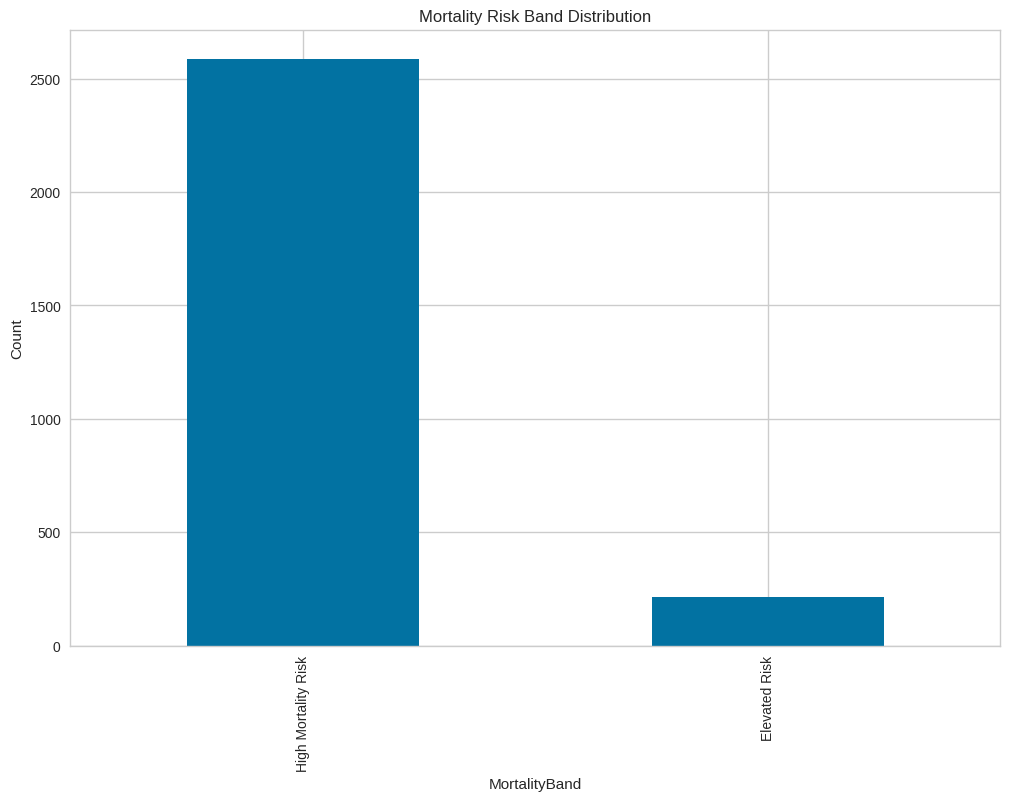

In [33]:
mort_df["MortalityBand"].value_counts().plot(kind="bar")
plt.title("Mortality Risk Band Distribution")
plt.ylabel("Count")
plt.show()

#### **Histograms**

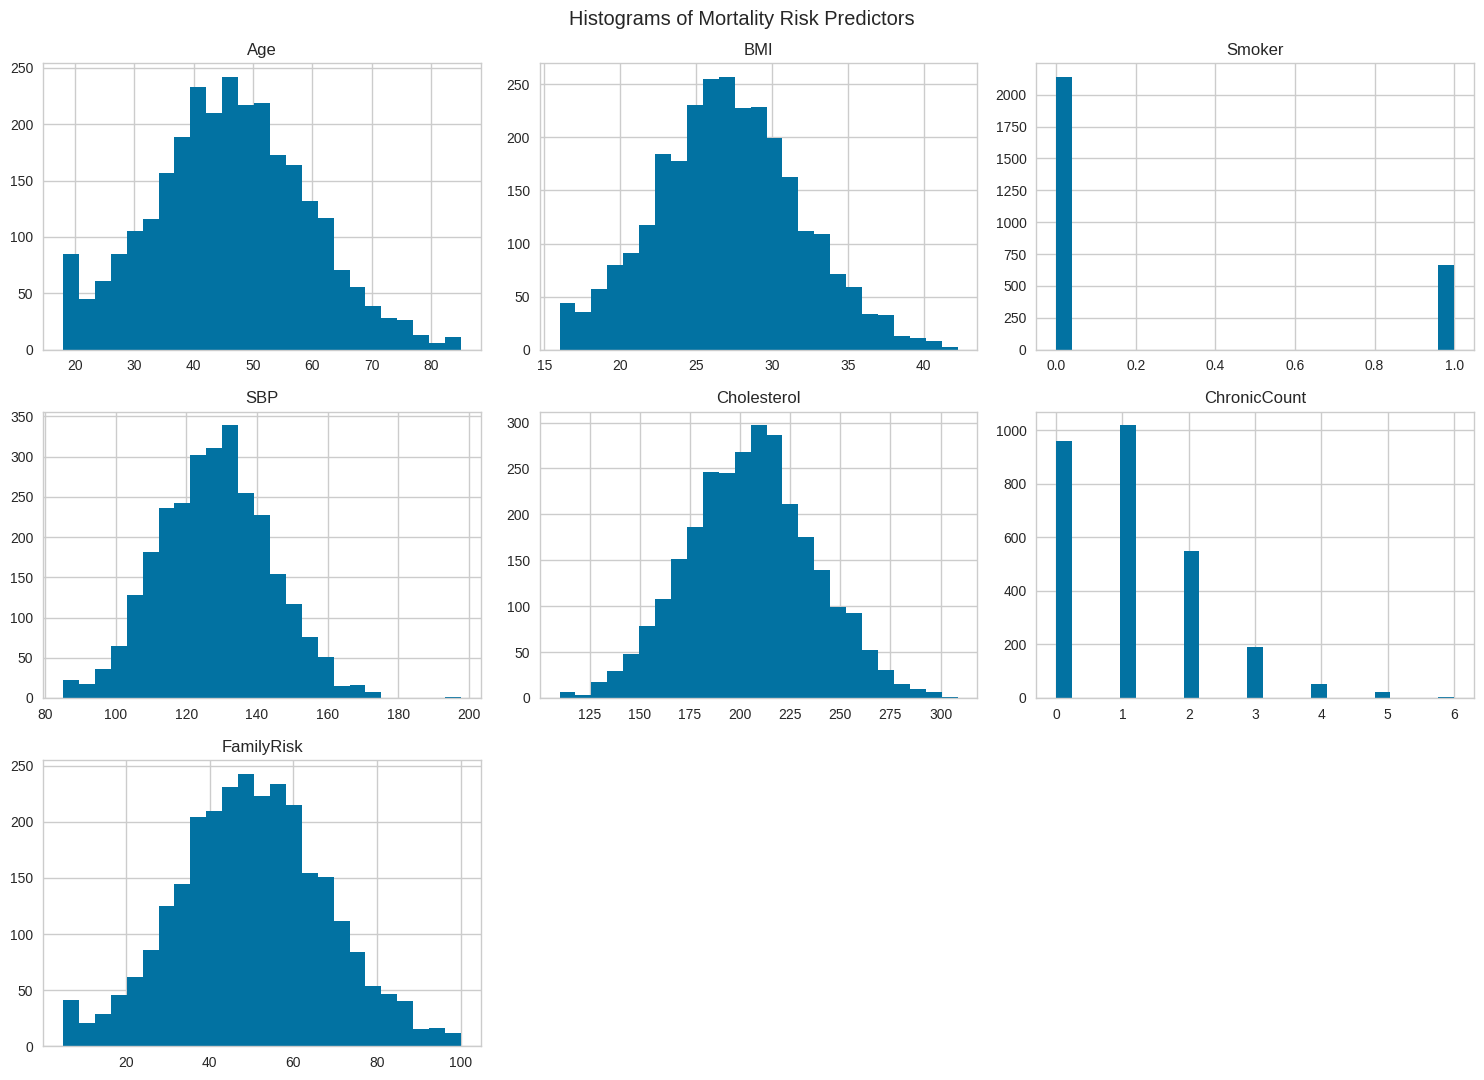

In [34]:
mort_df.hist(figsize=(15, 11), bins=25)
plt.suptitle("Histograms of Mortality Risk Predictors")
plt.tight_layout()
plt.show()

#### **Boxplots by class**

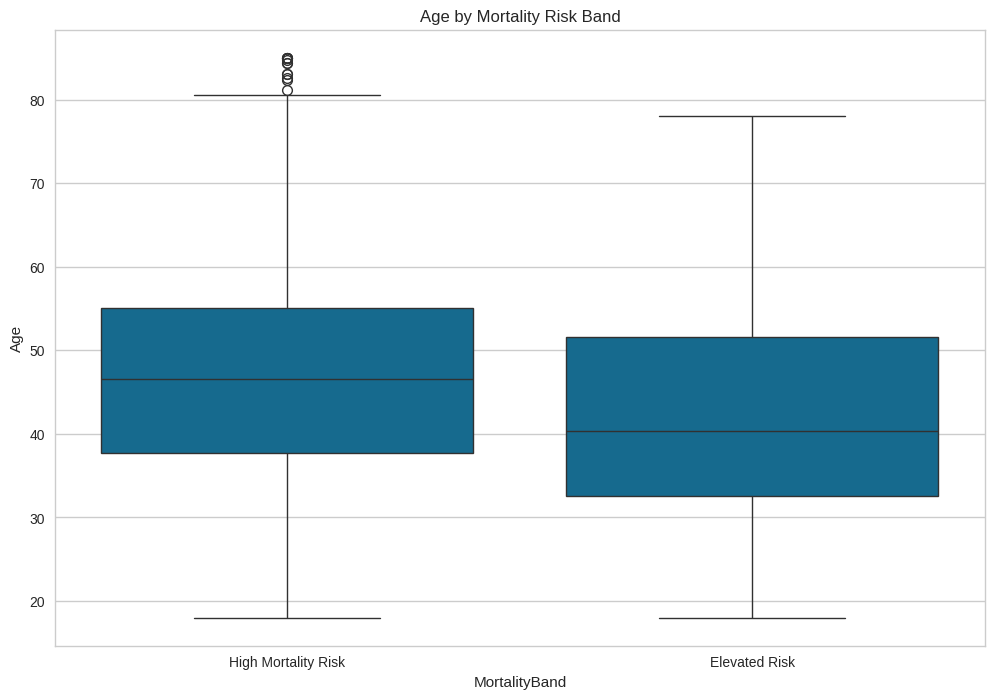

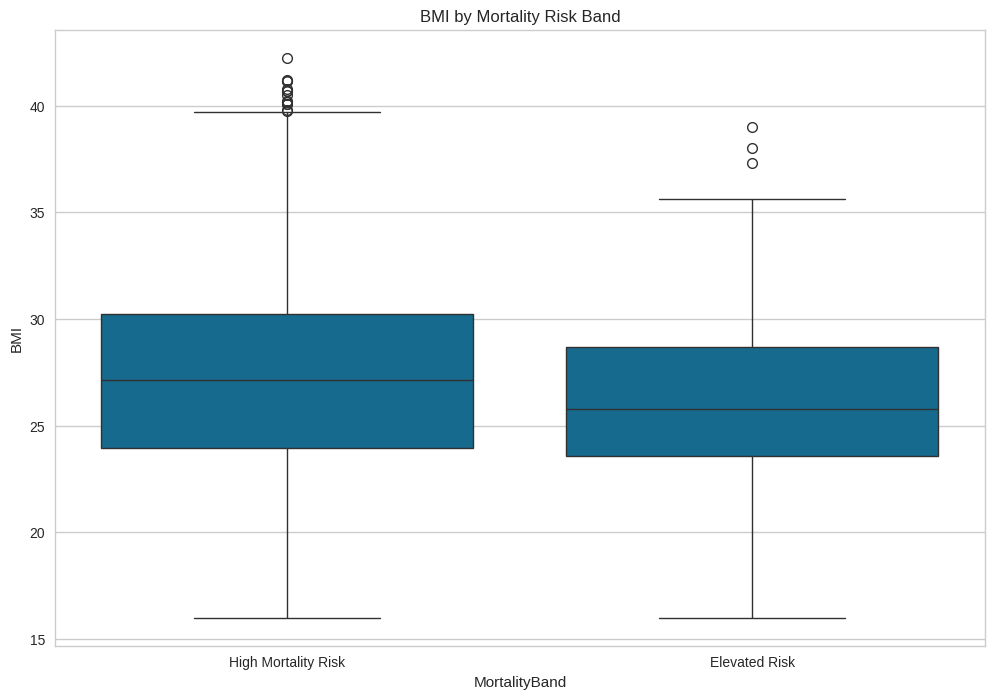

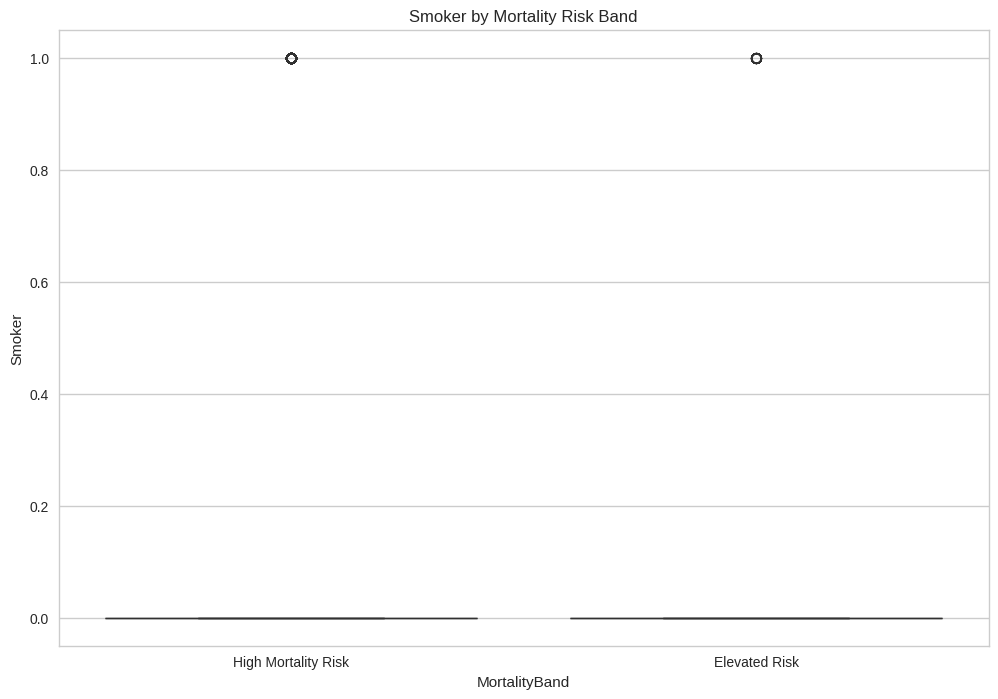

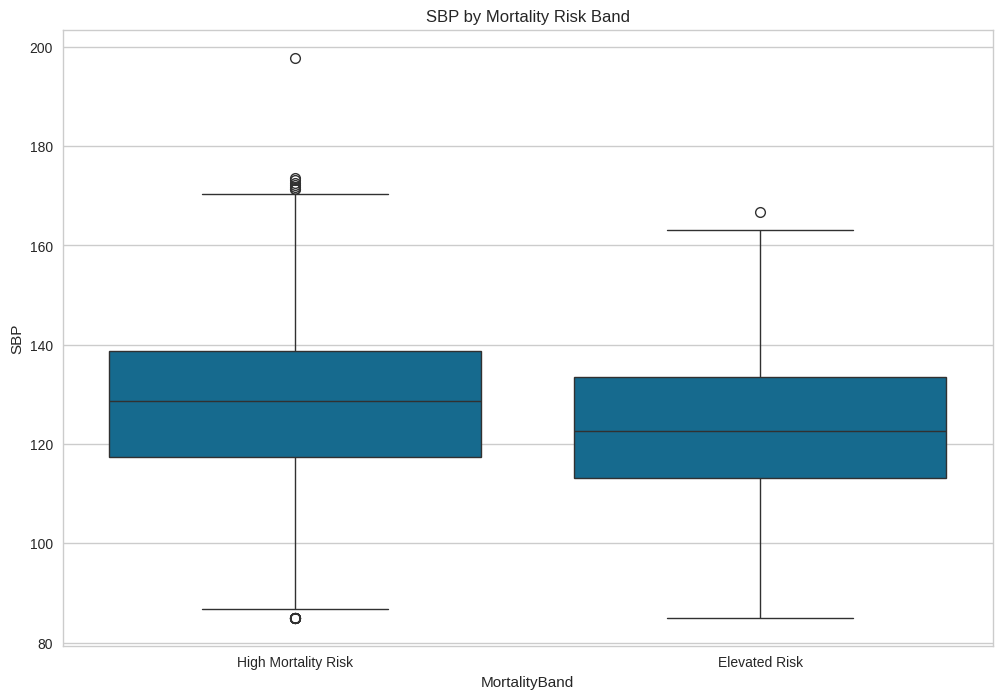

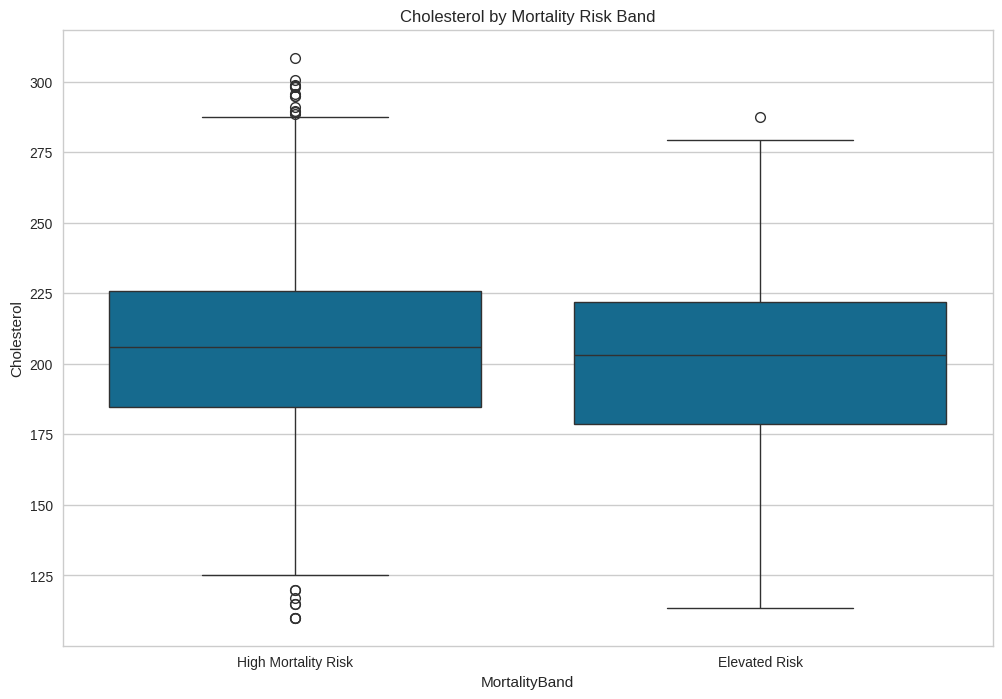

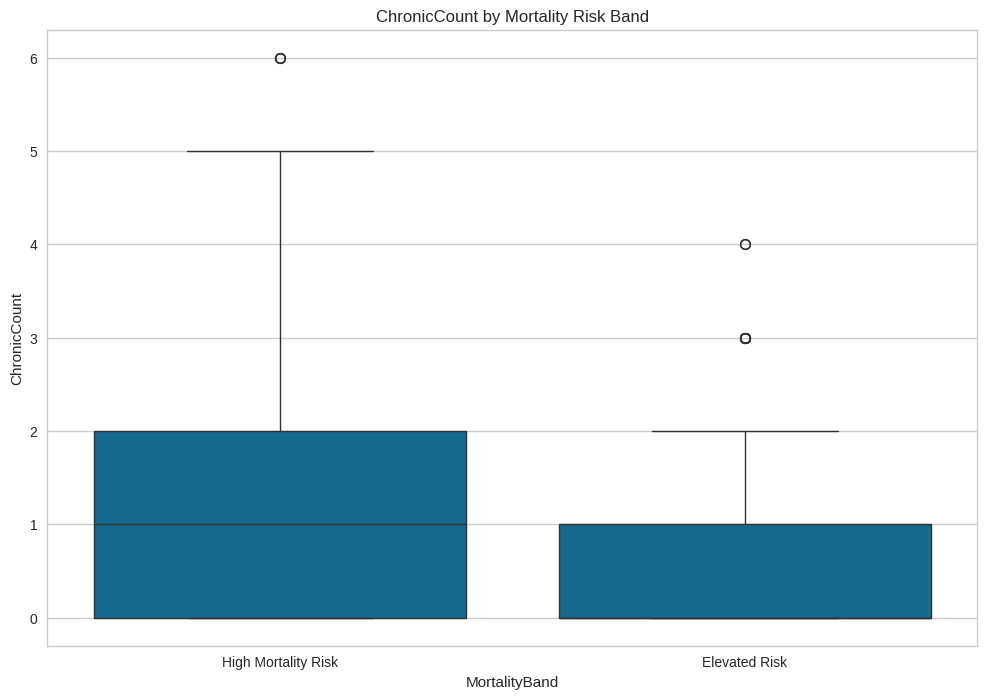

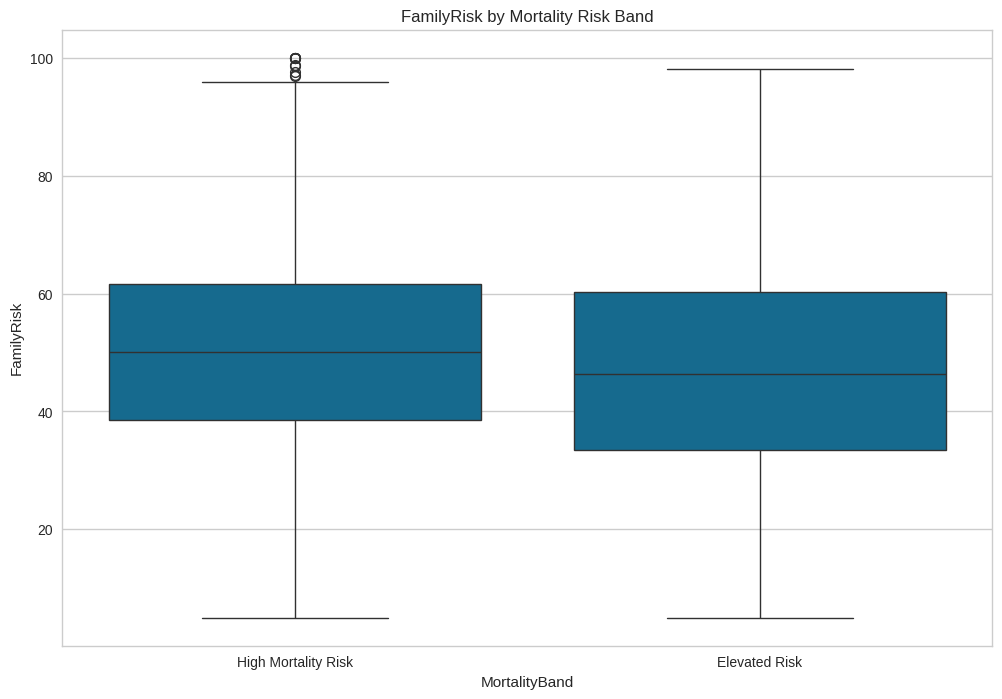

In [35]:
for col in ["Age", "BMI", "Smoker", "SBP", "Cholesterol", "ChronicCount", "FamilyRisk"]:
  sns.boxplot(data=mort_df, x="MortalityBand", y=col)
  plt.title(f"{col} by Mortality Risk Band")
  plt.show()

#### **Correlation heatmap**

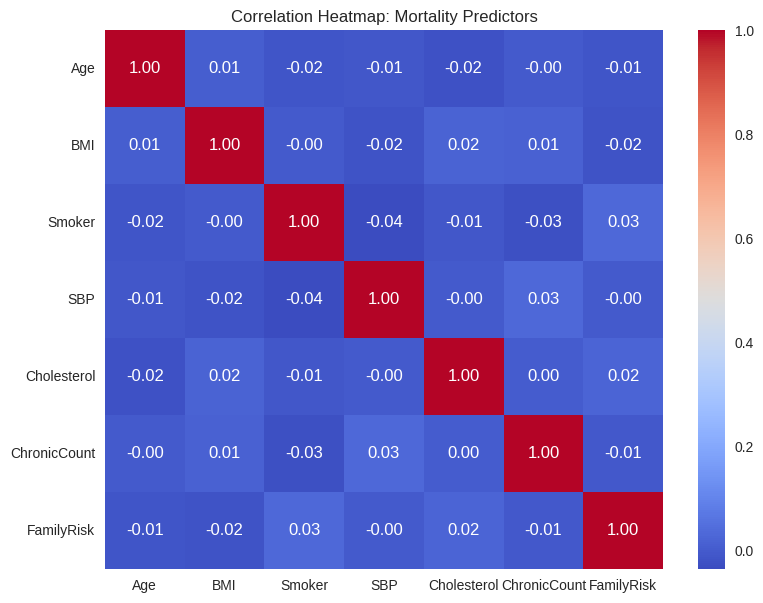

In [36]:
plt.figure(figsize=(9, 7))
sns.heatmap(mort_df.drop(columns="MortalityBand").corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap: Mortality Predictors")
plt.show()

#### **Pairplot**

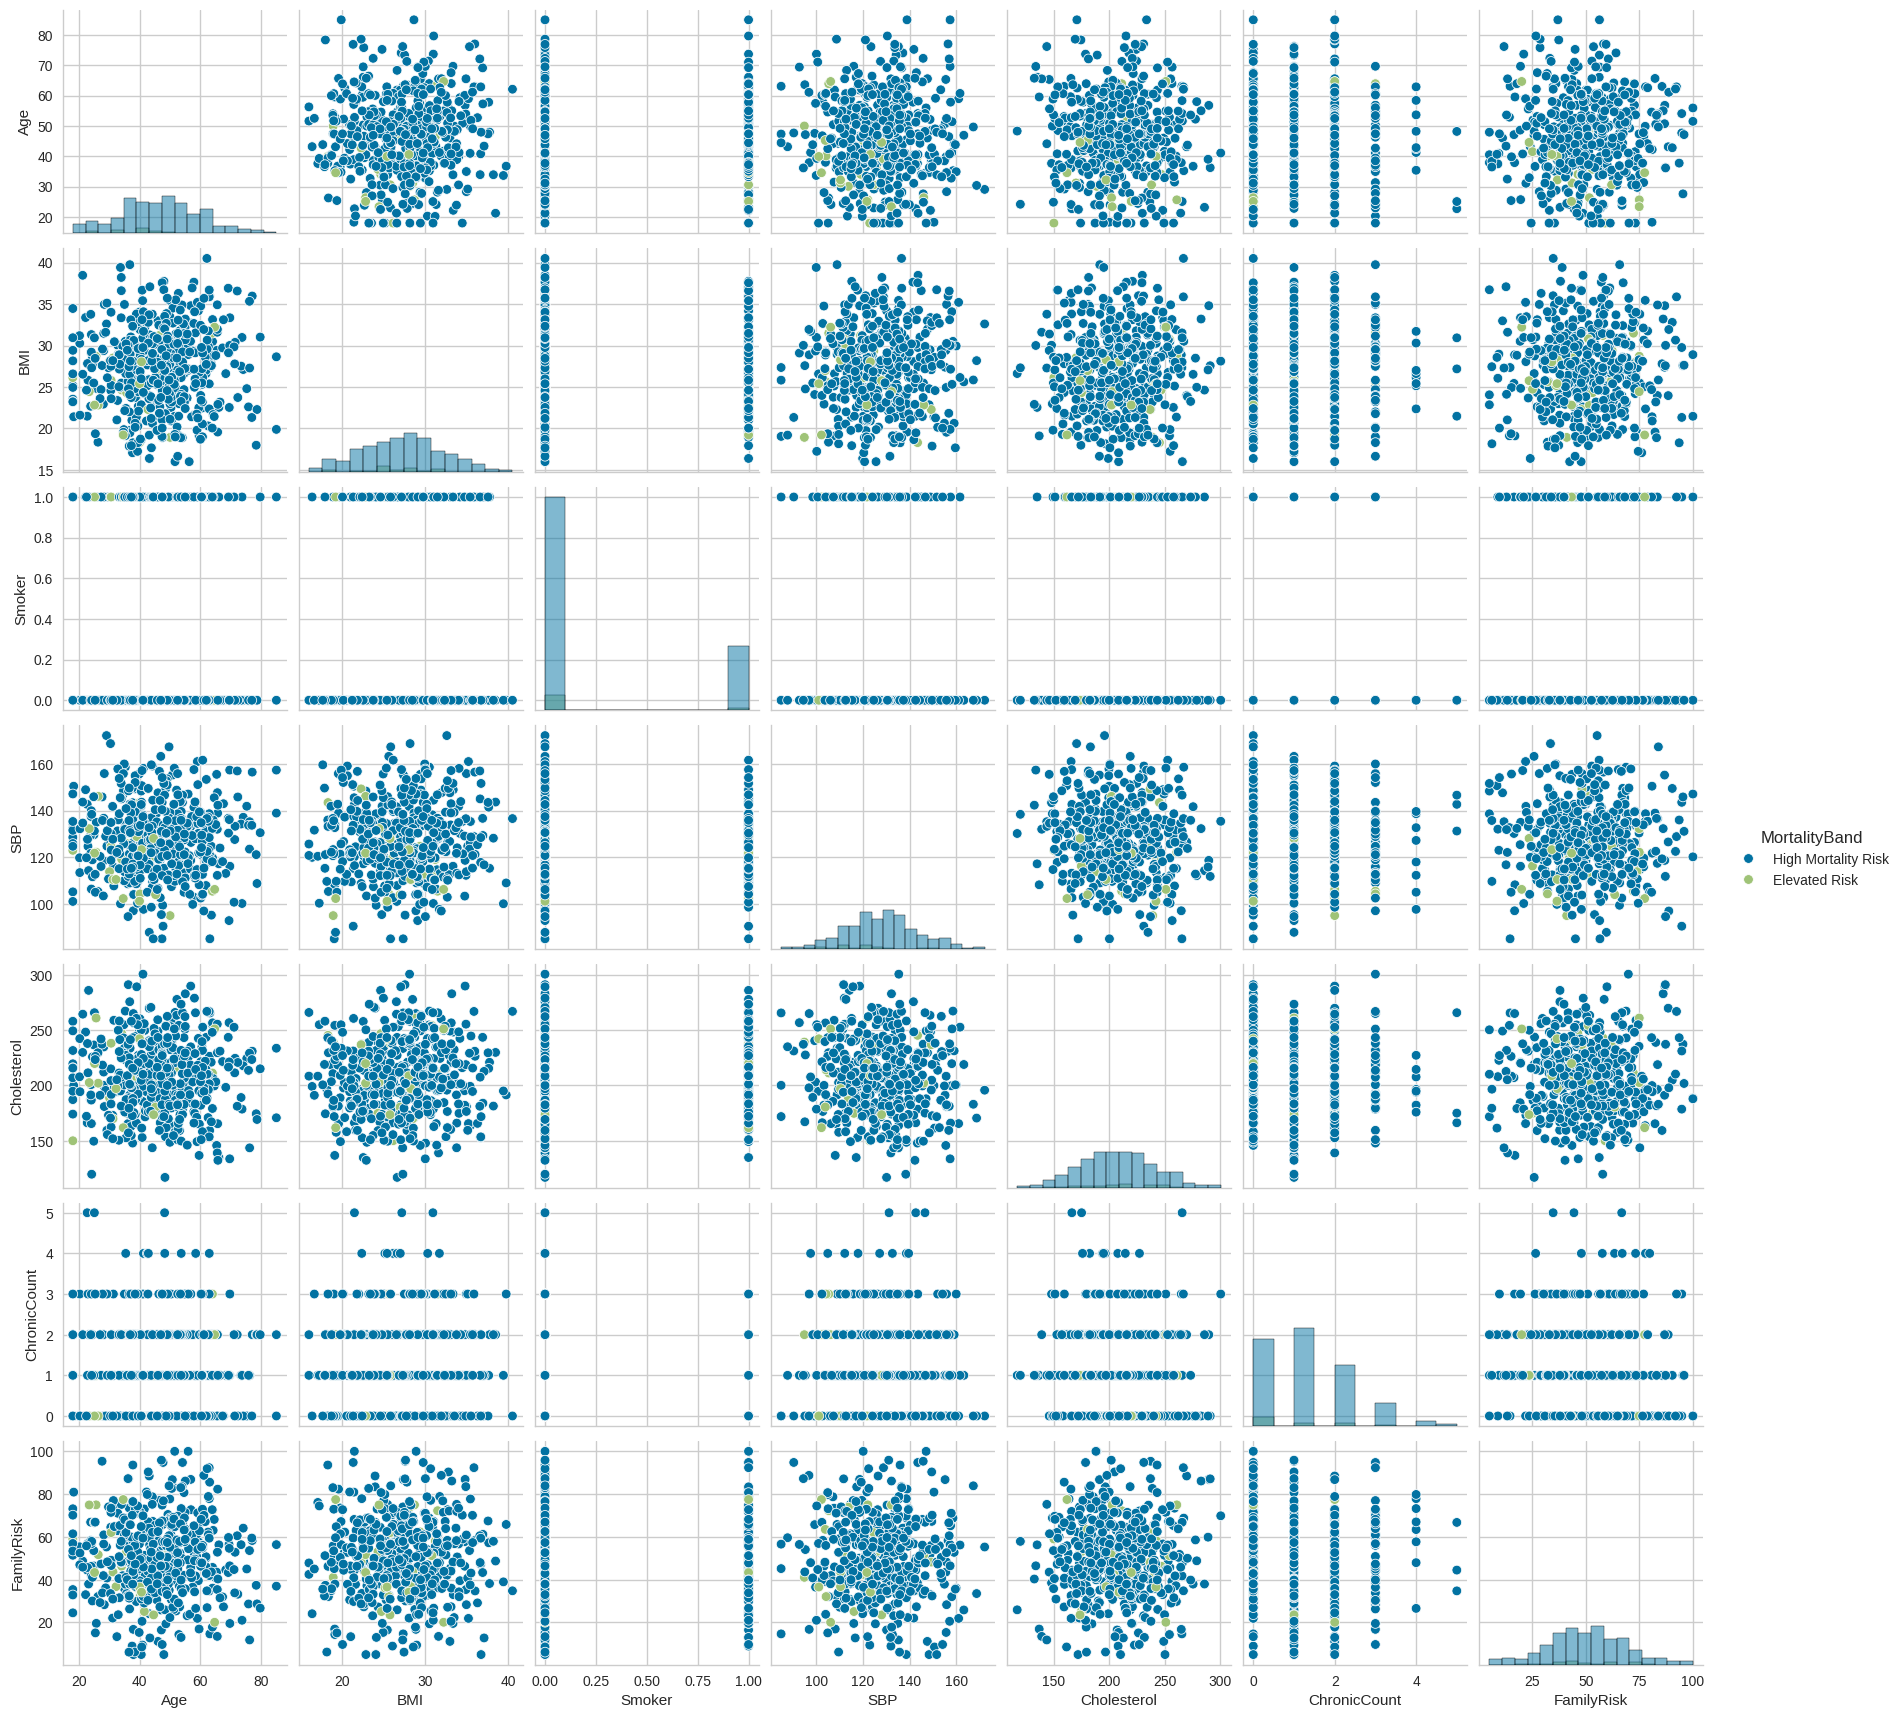

In [37]:
sns.pairplot(
  mort_df.sample(500, random_state=42),
  hue="MortalityBand",
  diag_kind="hist"
)
plt.show()

#### **Fit and evaluate the mortality model**

In [38]:
X3 = mort_df.drop(columns="MortalityBand")
y3 = mort_df["MortalityBand"]

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.30, random_state=42, stratify=y3
)

mort_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        multi_class="multinomial",
        solver="lbfgs",
        max_iter=2000
    ))
])

mort_model.fit(X3_train, y3_train)
y3_pred = mort_model.predict(X3_test)
y3_prob = mort_model.predict_proba(X3_test)

print("Accuracy:", accuracy_score(y3_test, y3_pred))

report = classification_report(y3_test, y3_pred)
print(report)

Accuracy: 0.9238095238095239
                     precision    recall  f1-score   support

      Elevated Risk       0.00      0.00      0.00        64
High Mortality Risk       0.92      1.00      0.96       776

           accuracy                           0.92       840
          macro avg       0.46      0.50      0.48       840
       weighted avg       0.85      0.92      0.89       840



In [39]:
display(plot_classification_report(y3_test, y3_pred))

,precision,recall,f1-score,support
Elevated Risk,0.000,0.000,0.000,64.000
High Mortality Risk,0.924,1.000,0.960,776.000
accuracy,0.924,0.924,0.924,0.924
macro avg,0.462,0.500,0.480,840.000
weighted avg,0.853,0.924,0.887,840.000


#### **Confusion matrix**

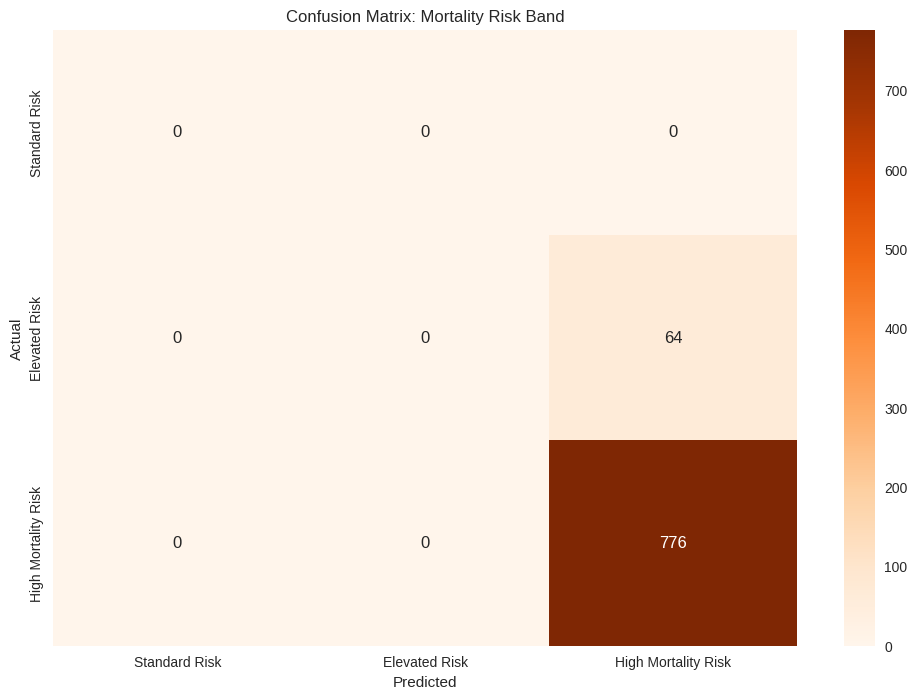

In [40]:
cm3 = confusion_matrix(y3_test, y3_pred, labels=mort_classes)
sns.heatmap(cm3, annot=True, fmt="d", cmap="Oranges",
            xticklabels=mort_classes, yticklabels=mort_classes)
plt.title("Confusion Matrix: Mortality Risk Band")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### **ROC curves**

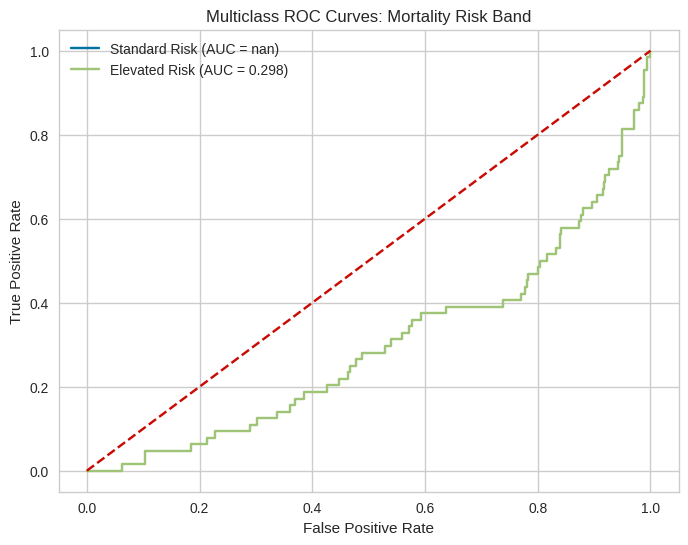

In [41]:
y3_test_bin = label_binarize(y3_test, classes=mort_classes)
plt.figure(figsize=(8, 6))

# Get the number of classes actually present in the model predictions
num_classes_in_model = y3_prob.shape[1]

for i in range(num_classes_in_model):
  cls = mort_classes[i]
  fpr, tpr, _ = roc_curve(y3_test_bin[:, i], y3_prob[:, i])
  roc_auc = auc(fpr, tpr)
  plt.plot(fpr, tpr, label=f"{cls} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("Multiclass ROC Curves: Mortality Risk Band")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

#### **Coefficient heatmap**

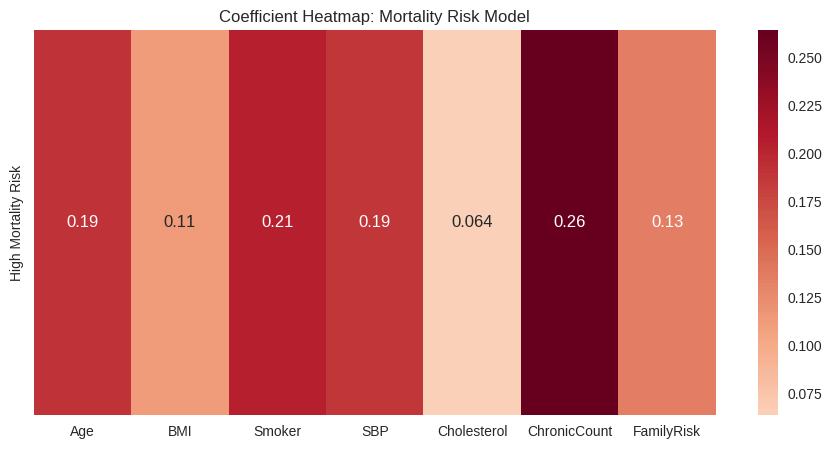

In [42]:
coef_df3 = pd.DataFrame(
    mort_model.named_steps["model"].coef_,
    columns=X3.columns,
    index=mort_model.named_steps["model"].classes_ if len(mort_model.named_steps["model"].classes_) > 2 else [mort_model.named_steps["model"].classes_[1]]
)

plt.figure(figsize=(11, 5))
sns.heatmap(coef_df3, annot=True, cmap="RdBu_r", center=0)
plt.title("Coefficient Heatmap: Mortality Risk Model")
plt.show()

#### **Scenario analysis**

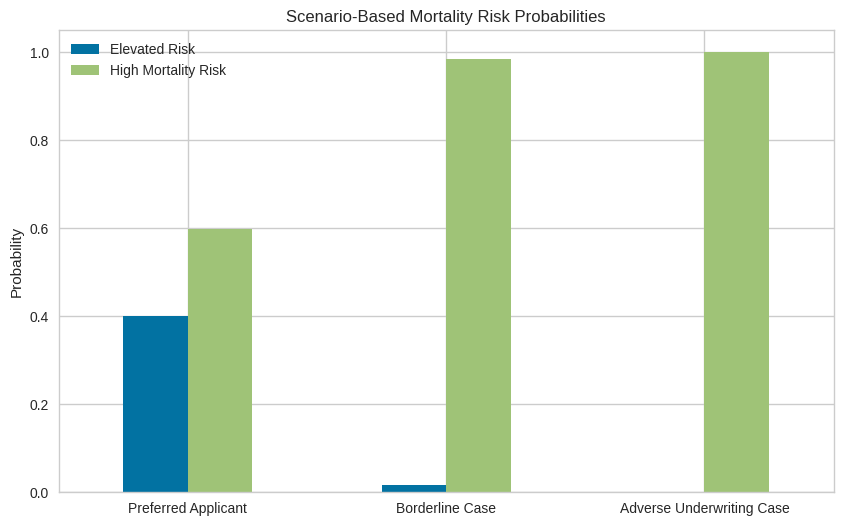

In [43]:
mort_scenarios = pd.DataFrame({
  "Age": [29, 52, 71],
  "BMI": [23, 29, 37],
  "Smoker": [0, 1, 1],
  "SBP": [112, 138, 165],
  "Cholesterol": [175, 220, 285],
  "ChronicCount": [0, 1, 4],
  "FamilyRisk": [20, 55, 88]
}, index=["Preferred Applicant", "Borderline Case", "Adverse Underwriting Case"])

mort_scenario_probs = pd.DataFrame(
  mort_model.predict_proba(mort_scenarios),
  columns=mort_model.named_steps["model"].classes_,
  index=mort_scenarios.index
)

mort_scenario_probs.plot(kind="bar", figsize=(10, 6))
plt.title("Scenario-Based Mortality Risk Probabilities")
plt.ylabel("Probability")
plt.xticks(rotation=0)
plt.show()

> *For underwriting-style segmentation, multinomial logistic regression offers a practical way to convert medical and lifestyle factors into explainable mortality risk bands.*